# **Projeto 2 - Machine Learning**

**Unidade Curricular:** Inteligência Artificial (L.EIC)  
**Group_A2_6:**
- António Santos, *up201705558*
- Miguel Neri, *up202006475*
- Vitor Pereira, *up202207715*

**Data:** 22/05/2026

--- 

<a id="indice"></a>
## **Índice**

1. [Business Understanding](#1-business-understanding)
    - 1.1. [Customer](#11-customer)
    - 1.2. [Problem](#12-problem)
    - 1.3. [Business goals](#13-business-goals)
    - 1.4. [ML goals](#14-ml-goals)
    - 1.5. [Solution overview](#15-solution-overview)
    - 1.6. [Stakeholders](#16-stakeholders)
    - 1.7. [Expected challenges](#17-expected-challenges)
    - 1.8. [Ethical risks](#18-ethical-risks)
2. [Data Understanding](#2-data-understanding)
    - 2.1. [Available data](#21-available-data)
    - 2.2. [Unavailable data](#22-unavailable-data)
    - 2.3. [Data description](#23-data-description)
    - 2.4. [Data exploration](#24-data-exploration)
    - 2.5. [Data quality assessment](#25-data-quality-assessment)
3. [Data Preparation](#3-data-preparation)
    - 3.1. [Synthetic data generation](#31-synthetic-data-generation)
    - 3.2. [Feature engineering](#32-feature-engineering)
    - 3.3. [Train/test split](#33-train-test-split)
4. [Modeling](#4-modeling)
    - 4.1. [Predictive model](#41-predictive-model)
    - 4.2. [Baseline model](#42-baseline)
    - 4.3. [Candidate models](#43-candidate-models)
    - 4.4. [Training pipelines](#44-training-pipelines)
    - 4.5. [Hyperparameter tuning](#45-hyperparameter-tuning)
5. [Evaluation](#5-evaluation)
    - 5.1. [Experimental setup](#51-experimental-setup)
    - 5.2. [Results](#52-results)
    - 5.3. [Error analysis](#53-error-analysis)
    - 5.4. [Discussion](#54-discussion)
6. [Deployment (Web App)](#6-deployment-web-app)
    - 6.1. [Web app overview](#61-web-app-overview)
    - 6.2. [Model persistence](#62-model-persistence)
    - 6.3. [Interface and usage](#63-interface-usage)
7. [Conclusions](#7-conclusions)
    - 7.1. [Summary of findings](#71-summary-findings)
    - 7.2. [Limitations](#72-limitations)
    - 7.3. [Future work](#73-future-work)

---

<a id="1-business-understanding"></a>
## **1. Business Understanding**

<a id="11-customer"></a>
### **1.1. Customer**

**Cliente:** *Gestivis, Lda.*, pequeno gabinete de contabilidade português com quatro colaboradores. Presta serviços de contabilidade organizada, fiscalidade e processamento salarial a uma carteira de 60 micro e pequenas empresas, incluindo empresários em nome individual.

O caso é relevante por representar um contexto comum no setor: equipas pequenas, relação próxima com os clientes e forte dependência da capacidade de planear tempo de trabalho. O tempo dos colaboradores é o recurso operacional mais crítico, pelo que a previsão da carga mensal tem impacto direto no planeamento, na revisão de avenças e na aceitação de novos clientes.

**Pessoa de contacto:** contabilista do gabinete, responsável pela validação das principais suposições de domínio.

<a id="12-problem"></a>
### **1.2. Problem**

O gabinete não consegue antecipar com fiabilidade **quantas horas de trabalho cada cliente vai exigir num determinado mês**. A incerteza afeta três decisões operacionais:

1. **Pricing desalinhado com o esforço real:** as avenças foram definidas sobretudo por estimativa qualitativa e são revistas com pouca frequência.
2. **Planeamento reativo:** a carga de trabalho só se torna clara à medida que os documentos chegam, aumentando o risco de picos junto dos prazos fiscais.
3. **Aceitação de novos clientes:** a estimativa inicial de esforço e de avença depende sobretudo da experiência da equipa.

Formalmente, trata-se de um problema de **regressão supervisionada**: para um cliente $c$ e um mês $m$, pretende-se estimar o número de horas de trabalho $\hat{y}_{c,m}$ que o gabinete irá dedicar a esse cliente nesse mês.

**Abordagem atual**

A estimativa de tempo é feita com base no conhecimento tácito da equipa. Este método é útil em carteiras pequenas e estáveis, mas não é facilmente mensurável, partilhável ou escalável. Também não permite simular cenários, como a entrada de um novo cliente ou a revisão objetiva de uma avença.

<a id="13-business-goals"></a>
### **1.3. Business goals**

A solução proposta apoia cinco objetivos de negócio:

| Objetivo | Descrição |
|---|---|
| **BG1. Planeamento mensal** | Antecipar a carga de trabalho por cliente e a carga agregada do mês. |
| **BG2. Identificação de clientes mal-precificados** | Comparar o esforço estimado com a avença atual. |
| **BG3. Deteção de consumo anómalo de tempo** | Sinalizar clientes cujo esforço real se desvia do esperado para o seu perfil. |
| **BG4. Apoio à aceitação de novos clientes** | Estimar o esforço provável de um cliente ainda sem histórico no gabinete. |
| **BG5. Cálculo de preço justo** | Apoiar a revisão de avenças com base em horas previstas e custo-hora de referência. |

O mesmo modelo preditivo suporta estes objetivos. A web app desenvolvida neste trabalho demonstra diretamente BG1, BG2 e BG4; BG3 e BG5 dependem de dados adicionais, sobretudo registo real de tempo e definição interna de custo-hora.

<a id="14-ml-goals"></a>
### **1.4. ML goals**

**Tarefa:** regressão supervisionada para prever $\hat{y}_{c,m}$, isto é, o número de horas de trabalho dedicadas ao cliente $c$ no mês $m$.

**Métricas de avaliação:**

- *MAE* (*Mean Absolute Error*), métrica principal por ser expressa diretamente em horas.
- *RMSE*, para penalizar erros grandes, relevantes no planeamento de capacidade.
- *R²*, para quantificar a fração da variância explicada pelo modelo.

**Critério de sucesso:** o modelo final deve reduzir o MAE do `DummyRegressor` em pelo menos 30% em validação cruzada. Com o baseline observado (MAE ≈ 2.17h no conjunto de teste), o objetivo prático é obter um erro claramente abaixo da previsão pela média. Este critério é mais robusto do que um limiar absoluto, porque ajusta a exigência à variabilidade efetiva do target.

**Requisitos não-funcionais:** interpretabilidade dos resultados, latência baixa na web app e capacidade de generalizar para clientes novos.

<a id="15-solution-overview"></a>
### **1.5. Solution overview**

A solução proposta é uma **ferramenta web interna** para apoiar a previsão e análise do tempo mensal por cliente. Inclui três componentes:

1. **Modelo preditivo:** modelo de regressão que estima horas de trabalho para cada par *(cliente, mês)*.
2. **Web app de apoio à decisão:** interface para previsão individual, previsão em lote e comparação entre horas previstas e avença atual.
3. **Integração futura com sistemas existentes:** numa fase posterior, os dados de entrada poderiam ser obtidos diretamente do software contabilístico e salarial do gabinete.

Os utilizadores previstos são o contabilista, para planeamento operacional, e o gerente do gabinete, para revisão de avenças e análise de novos clientes. O trabalho foca-se no modelo preditivo e numa demonstração funcional da aplicação.

<a id="16-stakeholders"></a>
### **1.6. Stakeholders**

O projeto envolve intervenientes do gabinete e da equipa técnica.

**Do lado do cliente:**

| Papel | Responsabilidade | Envolvimento |
|---|---|---|
| **Gerente do gabinete** | Valida objetivos de negócio, interpreta resultados estratégicos e decide eventual entrada em produção. | Todo o projeto |
| **Contabilista sénior** | Fornece conhecimento de domínio e valida a plausibilidade das suposições e dos resultados. | Todo o projeto |
| **Colaboradores do gabinete** | Utilizadores finais em cenário real; podem fornecer feedback sobre usabilidade e integração no fluxo de trabalho. | Validação e adoção |

**Do lado do desenvolvimento:**

| Papel | Responsabilidade | Envolvimento |
|---|---|---|
| **Data scientist / ML engineer** | Preparação dos dados, treino, avaliação e interpretação do modelo. | Todo o projeto |
| **Web developer** | Desenvolvimento da web app que consome o modelo treinado. | Deployment |
| **Gestor de projeto** | Gestão de requisitos, prazos e alinhamento com o cliente. | Todo o projeto |

No contexto académico, estes papéis são acumulados pelos elementos do grupo.

<a id="17-expected-challenges"></a>
### **1.7. Expected challenges**

O desenvolvimento e a eventual entrada em produção enfrentam desafios técnicos e organizacionais.

| Desafio | Descrição | Mitigação |
|---|---|---|
| **Ausência de *ground truth* fiável** | O gabinete não regista de forma sistemática o tempo por cliente e por mês. | Usar dados sintéticos nesta fase e, antes de produção, implementar um período-piloto de *time tracking*. |
| **Volume de dados limitado** | Uma carteira de 60 clientes com 36 meses gera cerca de 2 160 observações. | Privilegiar modelos simples, interpretáveis e com validação cuidadosa. |
| ***Concept drift*** | Clientes, processos e legislação mudam ao longo do tempo. | Retreino periódico e monitorização das métricas em produção. |
| **Resistência à medição de tempo** | A equipa pode interpretar a ferramenta como mecanismo de controlo individual. | Comunicar que o objetivo é estimar esforço por cliente, não avaliar colaboradores. |
| **Confiança excessiva no modelo** | Previsões numéricas podem ser interpretadas como verdades absolutas. | Mostrar incerteza, sinalizar casos de baixa fiabilidade e manter decisão humana. |
| **Comunicação de revisão de avenças** | Aumentos de preço podem afetar a relação com clientes finais. | Usar o modelo apenas como apoio interno à decisão comercial. |

<a id="18-ethical-risks"></a>
### **1.8. Ethical risks**

A solução é uma ferramenta interna de apoio à decisão. Não comunica diretamente com clientes finais nem trata categorias especiais de dados pessoais. Ainda assim, existem riscos relevantes:

| Risco | Descrição | Mitigação |
|---|---|---|
| **Uso como avaliação de colaboradores** | As previsões podem ser reinterpretadas como metas individuais de produtividade. | Explicitar que o modelo estima esforço por cliente, não desempenho individual. |
| **Justificação algorítmica de decisões comerciais** | O resultado pode ser usado para legitimar decisões já tomadas. | Exigir justificação humana adicional para alterações relevantes de avença. |
| **Falsa precisão** | Um valor como 12.7h pode transmitir objetividade excessiva. | Apresentar incerteza e sinalizar previsões de menor confiança. |
| **Confidencialidade** | Os atributos de entrada refletem informação sensível sobre clientes do gabinete. | Manter a solução em ambiente interno e aplicar minimização de dados. |

O projeto não se enquadra em categorias de alto risco do *AI Act* da UE, mas deve seguir boas práticas de transparência, segurança e supervisão humana.

*[Back to top](#indice)*

---

<a id="2-data-understanding"></a>
## **2. Data Understanding**

<a id="21-available-data"></a>
### **2.1. Available data**

O trabalho usa **dados sintéticos** que reproduzem, de forma controlada, a informação que um gabinete de contabilidade desta dimensão poderia ter disponível. A geração foi baseada nas tarefas descritas pela pessoa de contacto: organização documental, lançamentos contabilísticos, conciliação bancária, processamento salarial e obrigações fiscais.

Em contexto real, os dados estariam distribuídos por software contabilístico, software salarial, faturação interna e, idealmente, registos de tempo. Para este projeto, essa realidade foi simplificada em duas tabelas:

| Tabela | Granularidade | Conteúdo |
|---|---|---|
| `clientes` | 1 linha por cliente | Atributos estáveis: forma jurídica, setor, regimes fiscais, dimensão, antiguidade e avença atual. |
| `mensal_cliente` | 1 linha por cliente e mês | Volume mensal de atividade, obrigações fiscais, sazonalidade e target (`horas_totais`). |

A unidade de observação do modelo é o par *(cliente, mês)*. O target representa as horas totais dedicadas pelo gabinete a esse cliente nesse mês.

<a id="22-unavailable-data"></a>
### **2.2. Unavailable data**

Algumas variáveis seriam muito úteis num cenário real, mas não estão normalmente disponíveis de forma estruturada num gabinete pequeno.

| Dado | Valor potencial | Desafio de recolha |
|---|---|---|
| **Tempo real por cliente e mês** | Ground truth do problema. | Exige adoção consistente de *time tracking*. |
| **Tempo por tipo de tarefa** | Permite perceber onde se concentra o esforço. | Aumenta a carga de registo para os colaboradores. |
| **Qualidade dos documentos entregues** | Captura uma fonte importante de variação no tempo. | Requer classificação subjetiva e consistente. |
| **Comunicações com o cliente** | Telefonemas e emails explicam tempo não visível nos lançamentos. | Informação dispersa e pouco estruturada. |
| **Histórico de correções** | Identifica clientes que geram retrabalho. | Registos raramente centralizados. |

A evolução mais realista começaria por um período-piloto de *time tracking* durante 3 a 6 meses. Só depois faria sentido introduzir variáveis mais subjetivas, como qualidade documental.

<a id="23-data-description"></a>
### **2.3. Data description**

Esta secção formaliza o **esquema dos dados sintéticos** que vão ser gerados em 3.1. Funciona como a especificação que o gerador tem de respeitar.

**Janela temporal:** os dados representam 36 meses consecutivos terminando em **maio de 2026** (data do projeto), ou seja, de junho de 2023 a maio de 2026.

**Dimensões esperadas do dataset:**

| Tabela | Linhas (~) | Justificação |
|---|---|---|
| `clientes` | 60 | Carteira ativa do gabinete (informação fornecida pela pessoa de contacto). |
| `mensal_cliente` | ~2 160 | 60 clientes × 36 meses (3 anos de histórico). |

**Esquema da tabela `clientes` (atributos estáveis):**

| Atributo | Tipo | Domínio / Range | Notas |
|---|---|---|---|
| `cliente_id` | int | 1..60 | Identificador único |
| `forma_juridica` | categórico | {ENI, Unipessoal Lda., Lda., S.A.} | Distribuição enviesada para Lda. e Unipessoal Lda. |
| `setor` | categórico | {comércio, serviços, restauração, construção, indústria, profissional liberal} | Reflete a composição típica de uma carteira PME |
| `regime_iva` | categórico | {mensal, trimestral} | Maioria em trimestral (típico de micro-empresas) |
| `regime_contabilistico` | categórico | {organizada, simplificada} | Maioria em organizada |
| `dimensao_colaboradores` | int | 0..30 | Nº de colaboradores do cliente. Maioria com 0-5 |
| `antiguidade_meses` | int | 36..240 | Tempo como cliente do gabinete, em meses. Mínimo de 36 para garantir 3 anos completos de histórico mensal. |
| `avenca_atual_eur` | float | 50..500 | Avença mensal cobrada (€/mês) |

**Esquema da tabela `mensal_cliente` (uma linha por cliente × mês):**

| Atributo | Tipo | Domínio / Range | Notas |
|---|---|---|---|
| `cliente_id` | int | 1..60 | FK para `clientes` |
| `ano` | int | 2023..2026 | Cobre 3 anos de histórico (junho/2023 a maio/2026) |
| `mes` | int | 1..12 | Mês do ano |
| `nr_documentos` | int | 0..500 | Volume de documentos contabilísticos do mês |
| `nr_lancamentos` | int | 0..600 | Geralmente proporcional a `nr_documentos`, com algum ruído |
| `nr_colaboradores_processados` | int | 0..30 | Próximo de `dimensao_colaboradores`, com variação |
| `nr_movimentos_bancarios` | int | 0..200 | Volume de movimentos para conciliação |
| `tem_iva_a_entregar` | bool | {0, 1} | Depende do `regime_iva` e do mês |
| `tem_dmr` | bool | {0, 1} | 1 sempre que há colaboradores processados |
| `tem_modelo_22` | bool | {0, 1} | 1 apenas em maio (entrega de IRC) |
| `tem_ies` | bool | {0, 1} | 1 apenas em julho (entrega de IES) |
| `tem_irs_anual` | bool | {0, 1} | 1 em abril/junho (apoio a clientes particulares) |
| `eh_pico_fiscal` | bool | {0, 1} | 1 em meses com obrigações fiscais relevantes (abril, maio, julho) |
| `horas_totais` | float | 0..40 | **Target:** Horas dedicadas ao cliente naquele mês |

**Regras de negócio que os dados sintéticos devem respeitar:**

1. **Coerência cliente × mês:** `nr_lancamentos` deve ser aproximadamente proporcional a `nr_documentos` (com ruído); `nr_colaboradores_processados` deve estar próximo de `dimensao_colaboradores` (com variação por entradas/saídas).
2. **Sazonalidade fiscal:** os indicadores `tem_modelo_22`, `tem_ies` e `tem_irs_anual` só são 1 nos meses corretos do calendário fiscal português.
3. **Regime de IVA:** `tem_iva_a_entregar` é 1 todos os meses para clientes em regime mensal, e nos meses 2/5/8/11 para regime trimestral.
4. **Relação com o target:** `horas_totais` deve depender de forma plausível dos atributos de volume (positivamente correlacionada), do regime (organizada > simplificada), das obrigações ativas no mês e do número de colaboradores processados — com ruído gaussiano para evitar relações perfeitamente determinísticas.
5. **Variabilidade entre clientes:** dois clientes com volumes semelhantes podem ter `horas_totais` diferentes, refletindo a *qualidade dos documentos entregues* (variável que assumimos como latente — ver 2.2).

<a id="24-data-exploration"></a>
### **2.4. Data exploration**

Nesta secção exploramos o dataset gerado (ver 3.1. Synthetic data generation) para perceber as distribuições, identificar correlações e validar visualmente se as regras de negócio definidas em 2.3 foram respeitadas. As observações aqui registadas vão informar diretamente as decisões de 3.2 Feature engineering.

In [1]:
# Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import numpy as np
import time

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, GroupShuffleSplit, GridSearchCV

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

# Load data — use in-memory data if already generated,
# otherwise read the CSV files generated in section 3.1.
if "mensal_cliente" not in globals() or "clientes" not in globals():
    if Path("data/mensal_cliente.csv").exists():
        clientes = pd.read_csv("data/clientes.csv")
        mensal_cliente = pd.read_csv("data/mensal_cliente.csv")
    else:
        from data_generation import generate_dataset
        clientes, mensal_cliente = generate_dataset(seed=42, save_to="data/")

# Merge `clientes` and `mensal_cliente` for joint analysis
df = mensal_cliente.merge(clientes, on="cliente_id")
print(f"Dataset combinado: {df.shape[0]} linhas, {df.shape[1]} colunas")

Dataset combinado: 2160 linhas, 21 colunas


<a id="241-estatisticas-descritivas"></a>
#### **2.4.1. Estatísticas descritivas**

In [3]:
mensal_cliente.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
cliente_id,2160.0,30.50,17.32,1.00,15.75,30.50,45.25,60.00
ano,2160.0,2024.42,0.95,2023.00,2024.00,2024.00,2025.00,2026.00
mes,2160.0,6.50,3.45,1.00,3.75,6.50,9.25,12.00
nr_documentos,2160.0,33.21,19.54,3.00,20.00,29.00,42.00,149.00
nr_lancamentos,2160.0,38.26,22.93,3.00,23.00,34.00,48.00,171.00
nr_colaboradores_processados,2160.0,2.75,2.30,0.00,1.00,2.00,4.00,15.00
nr_movimentos_bancarios,2160.0,13.23,8.60,0.00,7.00,12.00,17.00,71.00
tem_iva_a_entregar,2160.0,0.57,0.50,0.00,0.00,1.00,1.00,1.00
tem_dmr,2160.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
tem_modelo_22,2160.0,0.08,0.28,0.00,0.00,0.00,0.00,1.00


In [4]:
for col in ["forma_juridica", "setor", "regime_iva", "regime_contabilistico"]:
    print(f"\n{col}:")
    print(clientes[col].value_counts().to_string())


forma_juridica:
forma_juridica
Unipessoal Lda.    25
Lda.               22
ENI                10
S.A.                3

setor:
setor
comércio                18
serviços                10
profissional liberal    10
restauração              8
construção               8
indústria                6

regime_iva:
regime_iva
trimestral    39
mensal        21

regime_contabilistico:
regime_contabilistico
organizada      47
simplificada    13


**Observações:**
- O target `horas_totais` tem média ~6h e mediana ~5.7h, com máximo ~19h. A diferença média/mediana sugere ligeira assimetria à direita (alguns clientes-mês muito "pesados").
- A distribuição categórica reflete o perfil pretendido: maioria em **regime trimestral de IVA** e **contabilidade organizada**; formas jurídicas dominadas por **Unipessoal Lda.** e **Lda.**; o setor mais frequente é **comércio**.
- A `dimensao_colaboradores` tem cauda longa: a maioria dos clientes tem poucos colaboradores e há alguns clientes maiores (até ~15), refletindo o tecido empresarial típico.

<a id="242-distribuicao-target"></a>
#### **2.4.2. Distribuição do target**

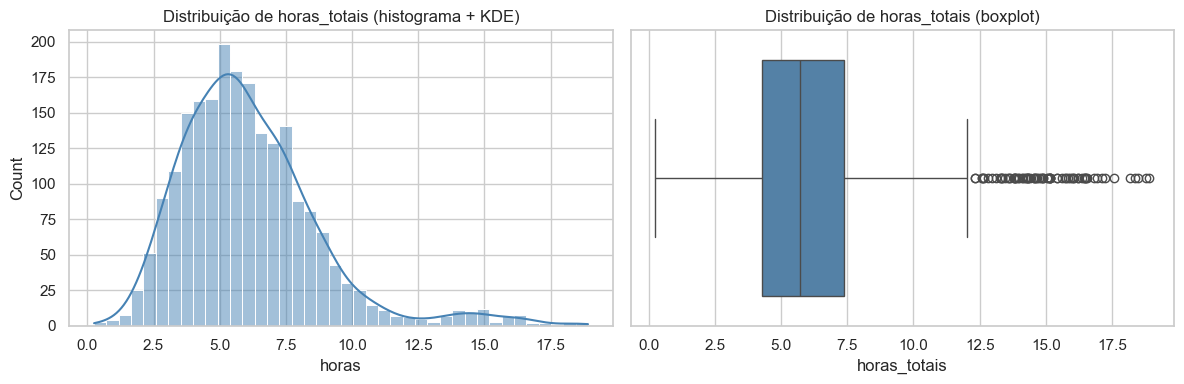

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(mensal_cliente["horas_totais"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição de horas_totais (histograma + KDE)")
axes[0].set_xlabel("horas")
sns.boxplot(x=mensal_cliente["horas_totais"], ax=axes[1], color="steelblue")
axes[1].set_title("Distribuição de horas_totais (boxplot)")
plt.tight_layout()
plt.show()

**Observações:**
- Distribuição **assimétrica à direita** (skew positivo): a maioria dos clientes-mês está entre 3 e 8 horas, mas a cauda estende-se até ~19h.
- Os "outliers" (pontos acima do bigode do boxplot) não são erros — correspondem a meses de pico fiscal (maio, julho) em clientes maiores. Devem ser **mantidos no dataset**, pois representam os casos mais interessantes para o gabinete antecipar.
- Para modelos sensíveis à distribuição do target (regressão linear), uma transformação logarítmica pode ser ponderada em 3.2 Feature engineering.

<a id="243-distribuicao-features"></a>
#### **2.4.3. Distribuição das features numéricas**

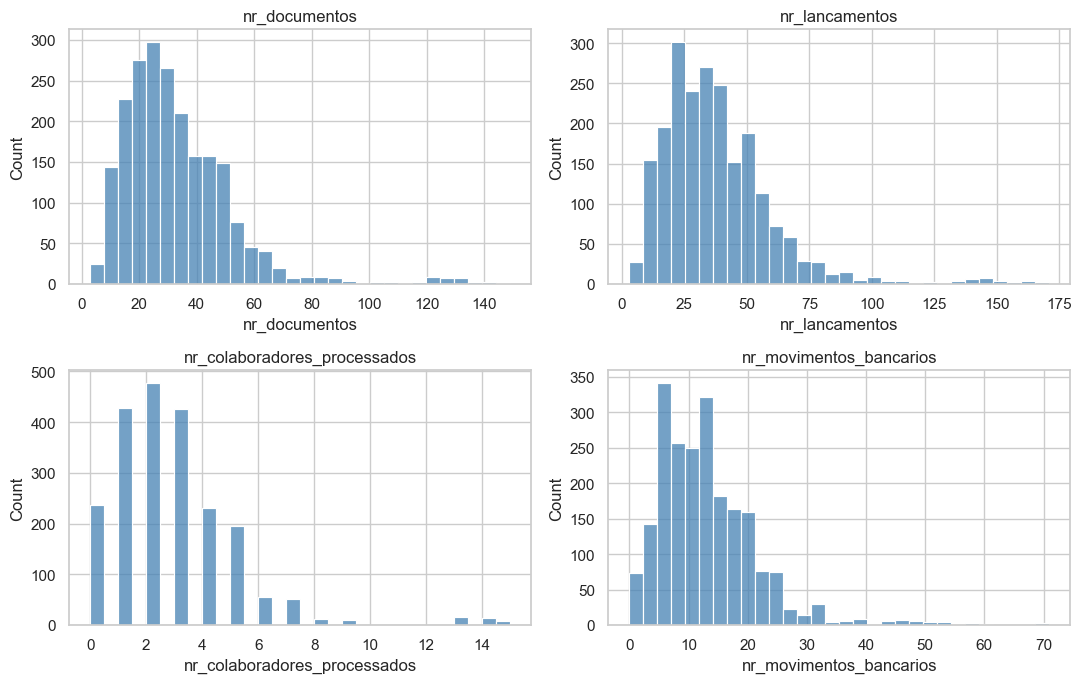

In [6]:
num_cols = ["nr_documentos", "nr_lancamentos",
            "nr_colaboradores_processados", "nr_movimentos_bancarios"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(mensal_cliente[col], bins=30, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observações:**
- Todas as features de volume têm distribuição **assimétrica à direita**, como seria de esperar para variáveis de contagem com cauda longa (Poisson/lognormal).
- As escalas variam significativamente: `nr_documentos` e `nr_lancamentos` em dezenas a centenas, `nr_colaboradores_processados` em unidades. Modelos baseados em distância exigiriam *standardization*.

<a id="244-target-categoricas"></a>
#### **2.4.4. Target em função das variáveis categóricas**

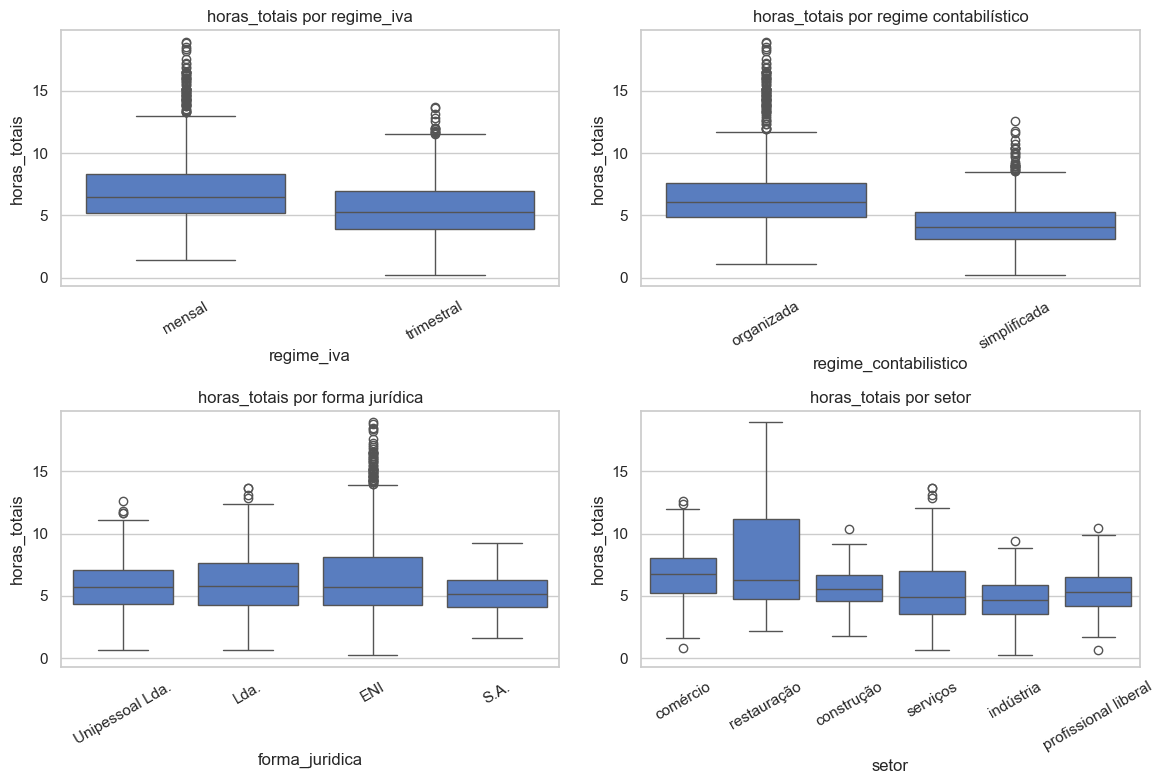

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cats = [("regime_iva", "regime_iva"),
        ("regime_contabilistico", "regime contabilístico"),
        ("forma_juridica", "forma jurídica"),
        ("setor", "setor")]
for ax, (col, title) in zip(axes.flat, cats):
    sns.boxplot(data=df, x=col, y="horas_totais", ax=ax)
    ax.set_title(f"horas_totais por {title}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Observações:**
- `regime_iva` **mensal > trimestral**: clientes em regime mensal consomem claramente mais horas (mais entregas anuais de IVA → mais trabalho recorrente). É um **preditor útil**.
- `regime_contabilistico` **organizada > simplificada**: diferença marcada e consistente com o conhecimento de domínio (contabilidade organizada exige mais trabalho). Outro **preditor útil**.
- `forma_juridica` mostra diferenças pequenas e ruidosas — provavelmente **pouco informativa** como feature isolada. Pode ser dropada ou agrupada (ex: ENI vs. resto).
- `setor` mostra algumas diferenças (restauração ligeiramente acima), mas a sobreposição entre setores é grande. **Marginalmente informativa**.

<a id="245-matriz-correlacao"></a>
#### **2.4.5. Matriz de correlação**

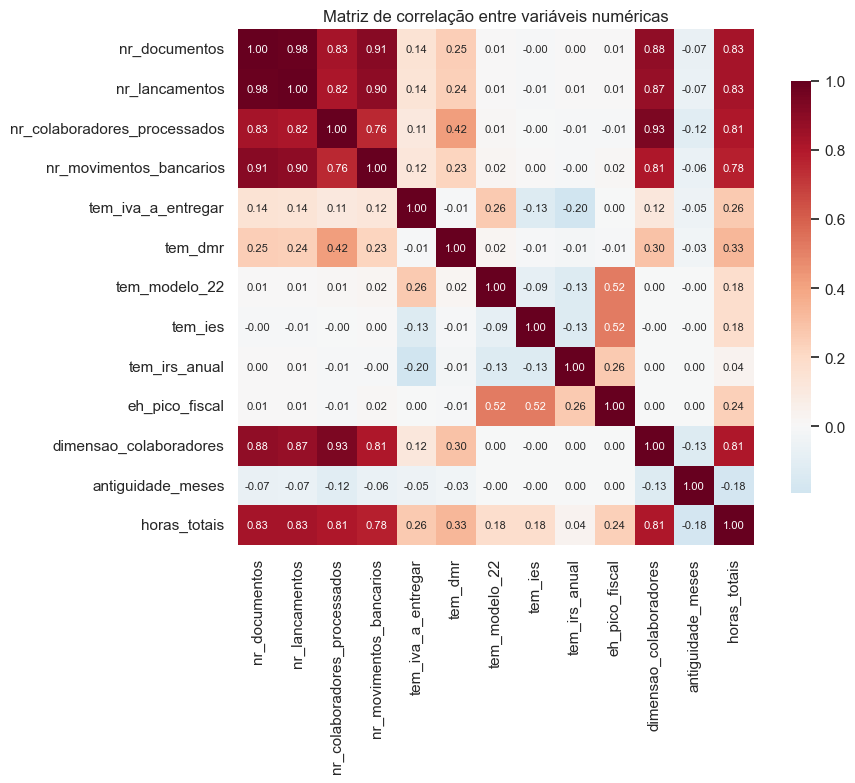

In [8]:
num_features = ["nr_documentos", "nr_lancamentos", "nr_colaboradores_processados",
                "nr_movimentos_bancarios", "tem_iva_a_entregar", "tem_dmr",
                "tem_modelo_22", "tem_ies", "tem_irs_anual", "eh_pico_fiscal",
                "dimensao_colaboradores", "antiguidade_meses", "horas_totais"]
corr = df[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"shrink": 0.8}, square=True, annot_kws={"size": 8})
plt.title("Matriz de correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

In [9]:
# Correlations sorted by target association
corr["horas_totais"].drop("horas_totais").sort_values(ascending=False).round(3)

nr_lancamentos                  0.830
nr_documentos                   0.830
nr_colaboradores_processados    0.812
dimensao_colaboradores          0.808
nr_movimentos_bancarios         0.777
tem_dmr                         0.329
tem_iva_a_entregar              0.263
eh_pico_fiscal                  0.242
tem_modelo_22                   0.177
tem_ies                         0.176
tem_irs_anual                   0.040
antiguidade_meses              -0.181
Name: horas_totais, dtype: float64

**Observações — correlações com o target:**

| Grupo | Correlação | Interpretação |
|---|---|---|
| Features de volume (`nr_documentos`, `nr_lancamentos`, `nr_colaboradores_processados`, `dimensao_colaboradores`, `nr_movimentos_bancarios`) | 0.78 – 0.83 | Forte. São os principais drivers do tempo, como esperado. |
| Indicadores de obrigações (`tem_dmr`, `tem_iva_a_entregar`, `eh_pico_fiscal`, `tem_modelo_22`, `tem_ies`) | 0.18 – 0.33 | Moderada. Adicionam informação útil para meses específicos. |
| `tem_irs_anual` | 0.04 | Praticamente nula. Apoio a clientes particulares com IRS é raro neste dataset. Candidato a ser dropado. |
| `antiguidade_meses` | -0.18 | Pequena correlação negativa, espúria (não foi modelada como causal). Reflete a aleatoriedade do gerador. Não esperamos sinal preditivo real. |

**Observações — multicolinearidade (problema importante):**

- `nr_documentos` ↔ `nr_lancamentos` = **0.98** — virtualmente redundantes.
- `nr_documentos` ↔ `nr_movimentos_bancarios` = **0.91** — fortemente correlacionadas.
- `nr_colaboradores_processados` ↔ `dimensao_colaboradores` = **0.93** — fortemente correlacionadas (esperado: o nº processado num mês é próximo do nº total).
- `dimensao_colaboradores` ↔ `nr_documentos` = **0.88** — clientes maiores geram mais documentos.

Isto exige decisões em 3.2 Feature engineering: manter algumas, eliminar outras ou combiná-las.

<a id="246-sazonalidade"></a>
#### **2.4.6. Análise de sazonalidade**

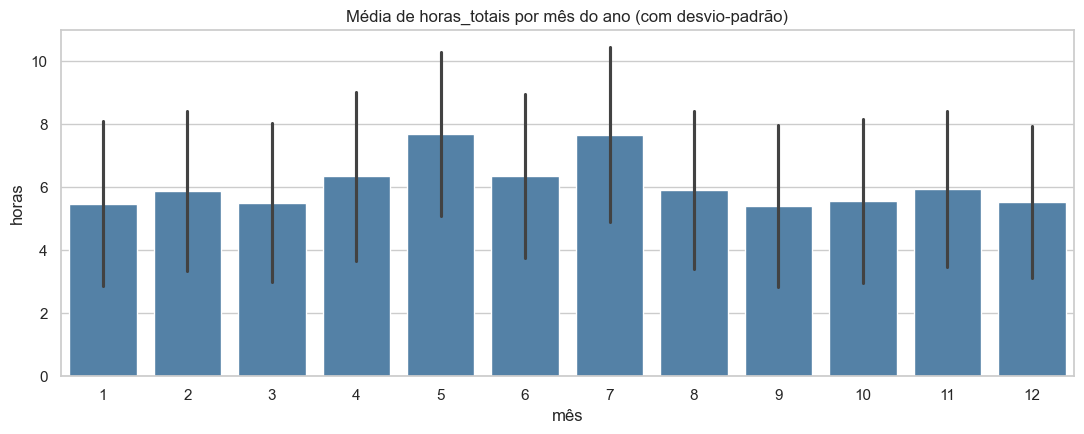

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=mensal_cliente, x="mes", y="horas_totais",
            errorbar="sd", ax=ax, color="steelblue")
ax.set_title("Média de horas_totais por mês do ano (com desvio-padrão)")
ax.set_xlabel("mês")
ax.set_ylabel("horas")
plt.tight_layout()
plt.show()

In [11]:
mensal_cliente.groupby("mes")["horas_totais"].agg(["mean", "std"]).round(2)

,mean,std
mes,,
1,5.48,2.62
2,5.88,2.53
3,5.51,2.52
4,6.34,2.67
5,7.68,2.61
6,6.35,2.60
7,7.67,2.78
8,5.90,2.51
9,5.41,2.58


**Observações:**
- **Maio** (~7.7h) e **julho** (~7.7h) destacam-se claramente — coincidem com os meses de entrega do **Modelo 22** (IRC, em maio) e da **IES** (em julho), validando a sazonalidade modelada.
- **Abril** (~6.3h) e **junho** (~6.4h) ficam ligeiramente acima da base, refletindo o **IRS anual** dos clientes particulares.
- Os restantes meses ficam consistentemente em torno de 5.5h. Este padrão é exatamente o que a regra #2 da 2.3 (sazonalidade fiscal) determina.
- **Implicação para o modelo:** features como `tem_modelo_22`, `tem_ies` e `eh_pico_fiscal` carregam informação relevante e devem ser mantidas, mesmo tendo correlações marginais (0.18-0.24) — o seu efeito é concentrado em poucos meses, o que dilui a correlação global mas mantém o valor preditivo.

<a id="247-sintese"></a>
#### **2.4.7. Síntese**

A exploração confirma que os dados sintéticos respeitam a especificação da 2.3 e oferecem padrões aprendíveis por modelos clássicos. Os principais *takeaways* para feature engineering e modelação:

1. **Features de volume são os principais drivers**, mas estão fortemente correlacionadas entre si (multicolinearidade) — exige decisão em 3.2.
2. **Regimes (IVA e contabilístico) são informativos** e devem ser codificados (one-hot ou ordinal).
3. **Setor e forma jurídica têm baixo poder preditivo** — candidatos a serem agregados ou eliminados para reduzir dimensionalidade.
4. **Sazonalidade fiscal é evidente** — features `tem_modelo_22`, `tem_ies`, `eh_pico_fiscal` capturam-na bem.
5. **`tem_irs_anual` tem correlação ~0** — candidato a ser removido.
6. **`antiguidade_meses` não tem sinal preditivo** real (correlação espúria) — candidato a ser removido.
7. **Distribuição do target é assimétrica** — ponderar transformação `log1p` para modelos lineares.

<a id="25-data-quality-assessment"></a>
### **2.5. Data quality assessment**

Esta secção avalia a qualidade dos dados gerados em 3.1. Synthetic data generation, em três dimensões: **completude** (valores em falta e duplicados), **conformidade com as regras de negócio** definidas em 2.3, e **identificação de outliers**.

<a id="251-completude"></a>
#### **2.5.1. Completude**

In [12]:
print("Valores em falta — clientes:")
print(clientes.isnull().sum().to_string())
print(f"\nValores em falta — mensal_cliente: {mensal_cliente.isnull().sum().sum()}")
print(f"\nDuplicados em clientes: {clientes.duplicated().sum()}")
print(f"Duplicados (cliente_id, ano, mes) em mensal_cliente: "
      f"{mensal_cliente.duplicated(subset=['cliente_id','ano','mes']).sum()}")

Valores em falta — clientes:
cliente_id                0
forma_juridica            0
setor                     0
regime_iva                0
regime_contabilistico     0
dimensao_colaboradores    0
antiguidade_meses         0
avenca_atual_eur          0

Valores em falta — mensal_cliente: 0

Duplicados em clientes: 0
Duplicados (cliente_id, ano, mes) em mensal_cliente: 0


Sem valores em falta nem duplicados — esperado, dado que o dataset é sintético e o gerador garante integridade por construção. Num cenário real este seria o ponto onde mais trabalho de limpeza seria necessário.

<a id="252-validacao-regras"></a>
#### **2.5.2. Validação das regras de negócio (2.3)**

In [13]:
# Validate the 5 business rules defined in section 2.3
df_valid = mensal_cliente.merge(clientes[["cliente_id", "regime_iva"]], on="cliente_id")

violacoes = {
    "IVA trimestral fora de fev/mai/ago/nov":
        ((df_valid["regime_iva"] == "trimestral")
         & (df_valid["tem_iva_a_entregar"] == 1)
         & (~df_valid["mes"].isin([2, 5, 8, 11]))).sum(),
    "IVA mensal sem entrega num dado mês":
        ((df_valid["regime_iva"] == "mensal")
         & (df_valid["tem_iva_a_entregar"] == 0)).sum(),
    "Modelo 22 fora de maio":
        ((mensal_cliente["tem_modelo_22"] == 1) & (mensal_cliente["mes"] != 5)).sum(),
    "IES fora de julho":
        ((mensal_cliente["tem_ies"] == 1) & (mensal_cliente["mes"] != 7)).sum(),
    "Inconsistência tem_dmr ↔ colaboradores processados":
        (((mensal_cliente["nr_colaboradores_processados"] > 0)
          & (mensal_cliente["tem_dmr"] == 0))
         | ((mensal_cliente["nr_colaboradores_processados"] == 0)
            & (mensal_cliente["tem_dmr"] == 1))).sum(),
}

for regra, n in violacoes.items():
    estado = "✓" if n == 0 else "✗"
    print(f"  {estado}  {regra}: {n} violações")

  ✓  IVA trimestral fora de fev/mai/ago/nov: 0 violações
  ✓  IVA mensal sem entrega num dado mês: 0 violações
  ✓  Modelo 22 fora de maio: 0 violações
  ✓  IES fora de julho: 0 violações
  ✓  Inconsistência tem_dmr ↔ colaboradores processados: 0 violações


Todas as regras de negócio são respeitadas, confirmando que o gerador implementa fielmente a especificação da 2.3.

<a id="253-outliers"></a>
#### **2.5.3. Outliers no target**

In [14]:
q1, q3 = mensal_cliente["horas_totais"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_sup = q3 + 1.5 * iqr
outliers = mensal_cliente[mensal_cliente["horas_totais"] > limite_sup]

print(f"Limite superior (Q3 + 1.5×IQR): {limite_sup:.2f}h")
print(f"Outliers detetados: {len(outliers)} ({100*len(outliers)/len(mensal_cliente):.1f}% do dataset)")
print(f"\nDistribuição dos outliers por mês:")
print(outliers["mes"].value_counts().sort_index().to_string())

Limite superior (Q3 + 1.5×IQR): 12.06h
Outliers detetados: 78 (3.6% do dataset)

Distribuição dos outliers por mês:
mes
1     6
2     6
3     6
4     7
5     8
6     6
7     9
8     6
9     6
10    6
11    6
12    6


Os 3-4% de pontos identificados como *outliers* estatísticos concentram-se em **abril, maio, junho e julho** — os meses de maior carga fiscal (IRS anual, Modelo 22, IES). Não são erros, são **casos legítimos** que o modelo deve aprender a prever — precisamente os que têm mais valor para o planeamento operacional. **Não devem ser removidos.**

<a id="254-sintese"></a>
#### **2.5.4. Síntese**

| Dimensão | Avaliação |
|---|---|
| Completude | ✓ Sem missings, sem duplicados |
| Conformidade com regras de negócio | ✓ Todas as 5 regras validadas em código |
| Ranges dos atributos | ✓ Validados em 2.3 (geração) |
| Outliers | ✓ Identificados; correspondem a casos legítimos (picos fiscais), a manter |
| Multicolinearidade | ⚠ Detetada em 2.4 — endereçada em 3.2 Feature engineering |
| Variáveis com baixo poder preditivo | ⚠ `tem_irs_anual`, `antiguidade_meses` — candidatas a remoção em 3.2 |

**Limitação fundamental (já discutida em 1.7 e 2.2):** todo este dataset é sintético. A *qualidade* aqui avaliada é a conformidade com a especificação — não há *ground truth* externo contra o qual validar os valores. Antes de qualquer utilização operacional, o modelo terá de ser revalidado com dados reais recolhidos pelo gabinete.

*[Back to top](#indice)*

---

<a id="3-data-preparation"></a>
## **3. Data Preparation**

<a id="31-synthetic-data-generation"></a>
### **3.1. Synthetic data generation**

A geração dos dados sintéticos segue o esquema e as regras de negócio definidos na secção de descrição dos dados. Para manter o notebook legível, o código está isolado no ficheiro `data_generation.py`.

**Organização do módulo:**

- `_gerar_clientes`: cria a tabela `clientes`, com distribuição coerente com uma carteira de micro e pequenas empresas portuguesas.
- `_gerar_calendario`: define 36 meses consecutivos, terminando em maio de 2026.
- `_aplicar_obrigacoes_fiscais`: aplica regras do calendário fiscal, incluindo Modelo 22, IES e IVA mensal/trimestral.
- `_calcular_horas_totais`: calcula o target com componentes de tempo por lançamentos, conciliação, salários e obrigações fiscais, acrescentando ruído gaussiano e uma variável latente de qualidade documental.

**Viés na geração dos dados:** a opção por um gerador em código, em vez de pedir a um LLM para gerar diretamente as linhas do dataset, reduz o risco de viés não auditável. Um LLM poderia produzir padrões plausíveis, mas com distribuições difíceis de controlar, inconsistências entre linhas e pressupostos implícitos sobre setores, dimensão ou regimes fiscais. O gerador em código também contém viés — porque reflete as regras e probabilidades escolhidas — mas esse viés fica explícito, reproduzível e verificável. Assim, as hipóteses podem ser discutidas, alteradas e testadas de forma transparente.

**Reproducibilidade:** o gerador usa `seed=42` por defeito, garantindo que a execução do notebook produz sempre o mesmo dataset.

**Persistência:** os DataFrames são guardados em `data/clientes.csv` e `data/mensal_cliente.csv` para utilização pela web app e pelos scripts de treino.

In [15]:
from data_generation import generate_dataset

clientes, mensal_cliente = generate_dataset(seed=42, save_to="data/")

print(f"clientes: {len(clientes):>5} linhas, {clientes.shape[1]} colunas")
print(f"mensal_cliente: {len(mensal_cliente):>5} linhas, {mensal_cliente.shape[1]} colunas")

clientes:    60 linhas, 8 colunas
mensal_cliente:  2160 linhas, 14 colunas


In [16]:
clientes.head()

,cliente_id,forma_juridica,setor,regime_iva,regime_contabilistico,dimensao_colaboradores,antiguidade_meses,avenca_atual_eur
0,1,Unipessoal Lda.,comércio,mensal,organizada,3,211,186.29
1,2,Unipessoal Lda.,restauração,trimestral,organizada,1,151,97.37
2,3,Unipessoal Lda.,comércio,trimestral,organizada,4,52,226.85
3,4,Lda.,construção,trimestral,organizada,5,192,235.03
4,5,Unipessoal Lda.,serviços,mensal,organizada,0,153,152.83


In [17]:
mensal_cliente.head()

,cliente_id,ano,mes,nr_documentos,nr_lancamentos,nr_colaboradores_processados,nr_movimentos_bancarios,tem_iva_a_entregar,tem_dmr,tem_modelo_22,tem_ies,tem_irs_anual,eh_pico_fiscal,horas_totais
0,1,2023,6,45,63,4,18,1,1,0,0,1,0,7.39
1,1,2023,7,34,41,2,14,1,1,0,1,0,1,6.65
2,1,2023,8,47,51,4,16,1,1,0,0,0,0,5.35
3,1,2023,9,39,52,4,15,1,1,0,0,0,0,4.98
4,1,2023,10,48,54,2,21,1,1,0,0,0,0,4.96


<a id="32-feature-engineering"></a>
### **3.2. Feature engineering**

Esta secção aplica as decisões informadas pela exploração (2.4.7 Síntese) para preparar o conjunto final de atributos que vão alimentar os modelos preditivos.

<a id="321-selecao-features"></a>
#### **3.2.1. Seleção e tratamento de atributos**

A tabela seguinte sumariza as decisões tomadas para cada atributo do dataset combinado:

| Atributo | Decisão | Justificação |
|---|---|---|
| `cliente_id` | Manter como **identificador** (não-feature) | Não tem sinal preditivo legítimo. Vai ser usado em 3.3 para garantir que o split não separa um mesmo cliente entre treino e teste. |
| `ano` | **Remover** | Não há tendência temporal modelada nos dados — `ano` é apenas uma etiqueta. |
| `mes` | **Manter** | Capta a posição no calendário (informação adicional aos indicadores de obrigações). |
| Features de volume (`nr_documentos`, `nr_lancamentos`, `nr_colaboradores_processados`, `nr_movimentos_bancarios`, `dimensao_colaboradores`) | **Manter todas** | Apesar da forte multicolinearidade detetada em 2.4.5, optou-se por não eliminar features e usar modelos robustos a colinearidade (Ridge, árvores de regressão). |
| Indicadores de obrigações fiscais (`tem_iva_a_entregar`, `tem_dmr`, `tem_modelo_22`, `tem_ies`, `eh_pico_fiscal`) | **Manter** | Correlação moderada (0.18–0.33) mas concentrada em meses específicos — alto valor preditivo nesses meses. |
| `tem_irs_anual` | **Remover** | Correlação ≈ 0.04 com o target (ver 2.4.5). |
| `antiguidade_meses` | **Remover** | Correlação espúria (–0.18), sem relação causal modelada. |
| `avenca_atual_eur` | **Remover** | Não deve ser feature: usá-la criaria um loop circular para o objetivo BG2 (comparar previsão com avença atual). É a *referência* contra a qual o resultado do modelo será comparado, não um input. |
| Variáveis categóricas (`forma_juridica`, `setor`, `regime_iva`, `regime_contabilistico`) | **Manter, codificadas via one-hot** | Mesmo as de sinal fraco (forma jurídica, setor) podem ser exploradas por modelos baseados em árvores. O custo de mantê-las é baixo (poucas categorias). |
| `horas_totais` | **Target** | Mantém-se como está. A transformação `log1p` foi considerada em 2.4.2, mas como são comparados modelos com sensibilidades diferentes à assimetria (lineares vs. árvores), aplicar log universalmente prejudicaria árvores. Em 4.1 pode ser usado seletivamente via `TransformedTargetRegressor` se necessário. |

<a id="322-construcao-dataset"></a>
#### **3.2.2. Construção do dataset de modelação**

In [18]:
# Combined dataset (recreate it if the previous cell was not executed)
if "df" not in globals():
    df = mensal_cliente.merge(clientes, on="cliente_id")

# Define column groups
ID_COL = "cliente_id"
TARGET = "horas_totais"

NUM_FEATURES = [
    "nr_documentos", "nr_lancamentos", "nr_colaboradores_processados",
    "nr_movimentos_bancarios", "tem_iva_a_entregar", "tem_dmr",
    "tem_modelo_22", "tem_ies", "eh_pico_fiscal",
    "dimensao_colaboradores", "mes",
]

CAT_FEATURES = [
    "forma_juridica", "setor", "regime_iva", "regime_contabilistico",
]

DROPPED = ["ano", "tem_irs_anual", "antiguidade_meses", "avenca_atual_eur"]

print(f"Numéricas mantidas:  {len(NUM_FEATURES)}")
print(f"Categóricas (a codificar): {len(CAT_FEATURES)}")
print(f"Removidas: {DROPPED}")

Numéricas mantidas:  11
Categóricas (a codificar): 4
Removidas: ['ano', 'tem_irs_anual', 'antiguidade_meses', 'avenca_atual_eur']


<a id="323-codificacao-categoricas"></a>
#### **3.2.3. Codificação de variáveis categóricas**

Aplicamos **one-hot encoding** com `drop_first=True` para evitar a *dummy variable trap* (multicolinearidade perfeita induzida por todas as dummies serem linearmente dependentes). Para cada variável categórica com `k` categorias, criamos `k-1` colunas binárias.

In [19]:
# Build X (features) and y (target) for modeling
X_raw = df[NUM_FEATURES + CAT_FEATURES + [ID_COL]].copy()
y = df[TARGET].copy()

# One-hot encode categorical variables
X = pd.get_dummies(X_raw, columns=CAT_FEATURES, drop_first=True, dtype=int)

print(f"X shape: {X.shape}  (inclui {ID_COL} como identificador, não-feature)")
print(f"y shape: {y.shape}")
print(f"\nFeatures finais (excluindo {ID_COL}): {X.shape[1] - 1}")
X.head()

X shape: (2160, 22)  (inclui cliente_id como identificador, não-feature)
y shape: (2160,)

Features finais (excluindo cliente_id): 21


,nr_documentos,nr_lancamentos,nr_colaboradores_processados,nr_movimentos_bancarios,tem_iva_a_entregar,tem_dmr,tem_modelo_22,tem_ies,eh_pico_fiscal,dimensao_colaboradores,...,forma_juridica_Lda.,forma_juridica_S.A.,forma_juridica_Unipessoal Lda.,setor_construção,setor_indústria,setor_profissional liberal,setor_restauração,setor_serviços,regime_iva_trimestral,regime_contabilistico_simplificada
0,45,63,4,18,1,1,0,0,0,3,...,0,0,1,0,0,0,0,0,0,0
1,34,41,2,14,1,1,0,1,1,3,...,0,0,1,0,0,0,0,0,0,0
2,47,51,4,16,1,1,0,0,0,3,...,0,0,1,0,0,0,0,0,0,0
3,39,52,4,15,1,1,0,0,0,3,...,0,0,1,0,0,0,0,0,0,0
4,48,54,2,21,1,1,0,0,0,3,...,0,0,1,0,0,0,0,0,0,0


<a id="324-features-derivadas"></a>
#### **3.2.4. Construção de features derivadas**

Foram criados dois atributos derivados com interpretação contabilística clara:

| Feature derivada | Cálculo | Interpretação | Tratamento de borda |
|---|---|---|---|
| `lancamentos_por_documento` | `nr_lancamentos / nr_documentos` | Densidade média de lançamentos por documento. | Se `nr_documentos = 0`, o valor é 0. |
| `documentos_por_colaborador` | `nr_documentos / dimensao_colaboradores` | Intensidade documental por colaborador. | Se `dimensao_colaboradores = 0`, usa-se `nr_documentos`. |

Nos dados sintéticos, espera-se que `lancamentos_por_documento` tenha poder preditivo limitado, porque o gerador define uma relação quase proporcional entre documentos e lançamentos. Ainda assim, a feature é mantida por ter fundamento de domínio e por poder ser mais útil em dados reais, onde a complexidade documental varia mais entre clientes.

In [20]:
# Feature 1: postings density per document
X["lancamentos_por_documento"] = np.where(
    X["nr_documentos"] > 0,
    X["nr_lancamentos"] / X["nr_documentos"],
    0.0,
)

# Feature 2: intensidade documental por colaborador
# Se 0 colaboradores (ENI), usar nr_documentos diretamente
X["documentos_por_colaborador"] = np.where(
    X["dimensao_colaboradores"] > 0,
    X["nr_documentos"] / X["dimensao_colaboradores"],
    X["nr_documentos"].astype(float),
)

print(f"X shape após features derivadas: {X.shape}")
X[["lancamentos_por_documento", "documentos_por_colaborador"]].describe().round(2)

X shape após features derivadas: (2160, 24)


,lancamentos_por_documento,documentos_por_colaborador
count,2160.00,2160.00
mean,1.15,14.14
std,0.10,5.98
min,0.82,3.00
25%,1.08,10.09
50%,1.15,13.00
75%,1.22,17.00
max,1.47,37.00


<a id="325-sintese-fe"></a>
#### **3.2.5. Síntese**

- **23 features finais** (21 originais após one-hot + 2 derivadas), num dataset com 2 160 observações.
- O rácio observações/features (~94:1) é confortável para modelos clássicos — bem acima do limiar de risco de *overfitting*.
- `cliente_id` mantido em `X` apenas como identificador, será **removido antes do treino** mas usado em 3.3 para guiar o split.
- Nenhuma feature de volume foi eliminada apesar da multicolinearidade: a estratégia é **escolher modelos robustos** em vez de remover informação.
- **Cleaning (CRISP-DM):** não há valores em falta, duplicados ou erros a tratar — o dataset é sintético e a sua qualidade foi verificada na análise de qualidade dos dados.
- **Scaling diferido ao pipeline:** as variáveis numéricas não estão normalizadas neste passo. Para modelos lineares regularizados, o *standardization* será aplicado **dentro de um `Pipeline` do scikit-learn** em 4.1 Predictive model, de modo a evitar *data leakage* durante a validação cruzada (os parâmetros do *scaler* têm de ser aprendidos apenas nos folds de treino). Para modelos baseados em árvores não é necessário.

<a id="33-train-test-split"></a>
### **3.3. Train/test split**

A escolha da estratégia de split é uma das decisões mais consequentes do projeto, pois define o que estamos a *avaliar*. Esta secção justifica a estratégia escolhida e implementa-a.

<a id="331-estrategia"></a>
#### **3.3.1. Estratégia escolhida — split por cliente**

Foram consideradas três estratégias:

| Estratégia | Pergunta avaliada | Decisão |
|---|---|---|
| **Split aleatório por linha** | Não responde a uma pergunta operacional útil. | Rejeitado, porque colocaria o mesmo cliente em treino e teste, criando *data leakage*. |
| **Split temporal** | O modelo prevê meses futuros de clientes conhecidos? | Rejeitado nesta fase porque o gerador não modela *concept drift* e a sazonalidade fiscal repete-se anualmente. |
| **Split por cliente** | O modelo generaliza para clientes nunca vistos? | Escolhido, por estar alinhado com o apoio à decisão sobre novos clientes. |

A proporção 70/30 gera 42 clientes de treino e 18 de teste. Esta escolha oferece um conjunto de teste suficientemente grande para avaliar generalização sem reduzir demasiado os dados de treino.

<a id="332-implementacao"></a>
#### **3.3.2. Implementação**

In [21]:
# `groups` indica, para cada linha, a que cliente pertence.
# GroupShuffleSplit ensures that no client appears in both train and test.
groups = X["cliente_id"].values
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

# Apply indices and remove cliente_id (identifier only, not a feature)
X_train = X.iloc[train_idx].drop(columns=["cliente_id"]).reset_index(drop=True)
X_test  = X.iloc[test_idx].drop(columns=["cliente_id"]).reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test  = y.iloc[test_idx].reset_index(drop=True)

# Save groups_train for later use in GroupKFold (cross-validation in section 5.1)
groups_train = X.iloc[train_idx]["cliente_id"].values

print(f"X_train: {X_train.shape}    y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}    y_test:  {y_test.shape}")

X_train: (1512, 23)    y_train: (1512,)
X_test:  (648, 23)    y_test:  (648,)


<a id="333-validacao-split"></a>
#### **3.3.3. Validação do split**

In [22]:
# 1. Check that no client overlaps between train and test
clientes_train = set(X.iloc[train_idx]["cliente_id"].unique())
clientes_test  = set(X.iloc[test_idx]["cliente_id"].unique())
sobreposicao = clientes_train & clientes_test

print(f"Clientes em treino: {len(clientes_train)}")
print(f"Clientes em teste:  {len(clientes_test)}")
print(f"Sobreposição:       {len(sobreposicao)}  (esperado: 0)")
assert len(sobreposicao) == 0, "FALHA: clientes cruzam entre treino e teste"

Clientes em treino: 42
Clientes em teste:  18
Sobreposição:       0  (esperado: 0)


In [23]:
# 2. Check that target distributions are comparable
print(f"y_train: média={y_train.mean():.2f}h, mediana={y_train.median():.2f}h, std={y_train.std():.2f}h")
print(f"y_test:  média={y_test.mean():.2f}h, mediana={y_test.median():.2f}h, std={y_test.std():.2f}h")

y_train: média=6.11h, mediana=5.84h, std=2.54h
y_test:  média=6.09h, mediana=5.42h, std=2.99h


In [24]:
# 3. Check that categories are reasonably balanced across splits
for col in ["regime_iva", "regime_contabilistico"]:
    train_dist = df.iloc[train_idx][["cliente_id", col]].drop_duplicates()[col].value_counts(normalize=True)
    test_dist  = df.iloc[test_idx][["cliente_id", col]].drop_duplicates()[col].value_counts(normalize=True)
    print(f"\n{col}:")
    print(f"  treino: {train_dist.round(2).to_dict()}")
    print(f"  teste:  {test_dist.round(2).to_dict()}")


regime_iva:
  treino: {'trimestral': 0.67, 'mensal': 0.33}
  teste:  {'trimestral': 0.61, 'mensal': 0.39}

regime_contabilistico:
  treino: {'organizada': 0.79, 'simplificada': 0.21}
  teste:  {'organizada': 0.78, 'simplificada': 0.22}


<a id="334-sintese-split"></a>
#### **3.3.4. Síntese**

- Estratégia: `GroupShuffleSplit` com `cliente_id` como grupo, 70/30 e `random_state=42`.
- Resultado: 42 clientes em treino (1 512 linhas) e 18 clientes em teste (648 linhas), sem sobreposição.
- As distribuições do target e das categorias mantêm-se comparáveis entre treino e teste.
- `groups_train` é guardado para usar `GroupKFold` na validação cruzada.

| Objeto | Shape | Descrição |
|---|---|---|
| `X_train` | (1 512, 23) | Features de treino, sem `cliente_id` |
| `X_test` | (648, 23) | Features de teste |
| `y_train` | (1 512,) | Target de treino |
| `y_test` | (648,) | Target de teste |
| `groups_train` | (1 512,) | Identificador de cliente por linha de treino |

*[Back to top](#indice)*

---

<a id="4-modeling"></a>
## **4. Modeling**

<a id="41-predictive-model"></a>
### **4.1. Predictive model**

Esta secção descreve **conceptualmente** o modelo preditivo que é desenvolvido. A implementação propriamente dita encontra-se distribuída pelas subsecções seguintes: o baseline em 4.2, os candidatos em 4.3, e os *pipelines* de treino em 4.4.

#### **4.1.1. Tarefa e formalização**

Tarefa de **regressão supervisionada** (já formalizada em 1.2 e 1.4):

$$\hat{y}_{c,m} = f(\mathbf{x}_{c,m})$$

Para cada par *(cliente $c$, mês $m$)*, o modelo $f$ recebe um vetor de atributos $\mathbf{x}_{c,m} \in \mathbb{R}^{23}$ e produz uma estimativa $\hat{y}_{c,m} \in [0, 40]$ de horas de trabalho.

- **Variável alvo:** `horas_totais` (contínua, em horas).
- **Atributos de entrada:** as 23 features finais definidas em 3.2.5 — 11 numéricas originais + 2 derivadas (lançamentos por documento e documentos por colaborador) + 10 dummies das categóricas.
- **Dataset:** 1 512 observações de treino (42 clientes) e 648 de teste (18 clientes), com split por cliente — ver 3.3.

#### **4.1.2. Critérios para a escolha da família de modelos**

A escolha dos algoritmos é guiada pelos **requisitos não-funcionais** definidos em 1.4 e pelas características do dataset reveladas em 2.4:

| Requisito / característica | Implicação para a escolha de modelo |
|---|---|
| **Interpretabilidade** (1.4) | Exclui redes neuronais. Privilegia modelos lineares (coeficientes) e árvores (regras *if-then*, importância de features). |
| **Baixa latência** (<1s, 1.4) | Todos os modelos clássicos satisfazem; árvores e regressões lineares fazem predição em microssegundos. |
| **Robustez a clientes novos** (1.4) | Privilegia modelos que generalizam bem com pouco *overfitting* (regularização ou *ensembles*). |
| **Volume de dados limitado** (~2 160 observações, 1.7) | Exclui modelos *data-hungry* (deep learning, gradient boosting com muitas árvores). |
| **Multicolinearidade forte** (até 0.98, 2.4.5) | Privilegia modelos robustos: regressão regularizada (penalização) ou árvores (invariantes a colinearidade). |

#### **4.1.3. Família de modelos escolhida**

São comparados um baseline e quatro candidatos:

1. **`DummyRegressor`** — prevê sempre a média de `y_train` e define a referência mínima de desempenho.
2. **`LinearRegression`** — regressão linear sem regularização, usada como referência linear simples.
3. **`Ridge`** — regressão linear com regularização L2, adequada perante multicolinearidade e mantendo interpretabilidade.
4. **`DecisionTreeRegressor`** — árvore de regressão, capaz de capturar não-linearidades e interações.
5. **`RandomForestRegressor`** — *ensemble* de árvores por *bagging*, geralmente forte em dados tabulares.

A seleção cobre modelos lineares, regularizados e baseados em árvores. Não foram usados modelos mais pesados, como *gradient boosting* ou redes neuronais, porque o dataset é pequeno e a interpretabilidade é um requisito central.

#### **4.1.4. Estratégia de treino e afinação**

- **Cross-validation:** `GroupKFold` com 5 folds usando `groups_train` (`cliente_id`), garantindo que nenhum cliente cruza entre folds de treino e validação — consistente com a estratégia de 3.3.
- **Hiperparâmetros:** **dois passos** — primeiro avaliar todos os candidatos com **valores por defeito** em 4.4, registando o desempenho *out-of-the-box*; depois realizar uma **afinação formal** via `GridSearchCV` em 4.5. Esta abordagem em duas fases:
    1. Estabelece um *benchmark* honesto do que se obtém sem afinação.
    2. Quantifica o ganho real da afinação.
    3. Mantém o tempo de execução do notebook controlado.
- **Métrica de seleção:** MAE médio em validação cruzada (definida como métrica primária em 1.4), com desvio-padrão como critério de desempate (preferir modelo mais estável).
- **Reproducibilidade:** todos os modelos com componente estocástica (`DecisionTreeRegressor`, `RandomForestRegressor`) usam `random_state=42`.

<a id="42-baseline"></a>
### **4.2. Baseline model**

Antes de comparar modelos, é definido um baseline simples: `DummyRegressor(strategy="mean")`, que prevê sempre a média de `y_train`.

Este baseline permite verificar se os modelos aprendem sinal real nos atributos. Também serve de referência para o critério de sucesso: o modelo final deve reduzir o MAE do baseline em pelo menos 30%.

#### **Implementação e cálculo de métricas**

O baseline é avaliado com MAE, RMSE e R² no conjunto de teste.

In [25]:
# Train the baseline (always predicts the mean of y_train)
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

# Predictions on the test set
y_pred_baseline = baseline.predict(X_test)

# Compute metrics
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline DummyRegressor (estratégia: média de y_train = {y_train.mean():.2f}h)")
print(f"  MAE  = {mae_baseline:.3f} h")
print(f"  RMSE = {rmse_baseline:.3f} h")
print(f"  R²   = {r2_baseline:.4f}")

Baseline DummyRegressor (estratégia: média de y_train = 6.11h)
  MAE  = 2.169 h
  RMSE = 2.992 h
  R²   = -0.0001


**Análise do baseline e implicação para o critério de sucesso:**

O `DummyRegressor` atinge **MAE ≈ 2.17h** por prever a média do target. O `R²` é próximo de zero, como esperado para um previsor constante.

Este resultado mostra que um limiar absoluto de erro seria pouco informativo. O critério final passa, por isso, a ser relativo ao baseline: o modelo deve reduzir o MAE em pelo menos 30%. Assim, confirma-se que o ganho resulta de sinal presente nas features e não apenas da distribuição do target.

<a id="43-candidate-models"></a>
### **4.3. Candidate models**

Esta secção define os quatro modelos candidatos treinados e comparados com o baseline.

#### **Candidato 1 — `LinearRegression`**

Regressão linear por mínimos quadrados ordinários, sem regularização. É usada como referência linear simples. Num problema com multicolinearidade forte, os coeficientes podem tornar-se instáveis, embora as previsões possam continuar competitivas.

#### **Candidato 2 — `Ridge`**

Regressão linear com regularização L2. A penalização reduz a magnitude dos coeficientes e melhora a estabilidade quando existem variáveis altamente correlacionadas. Por manter coeficientes interpretáveis, é um bom candidato para este domínio.

#### **Candidato 3 — `DecisionTreeRegressor`**

Árvore de regressão única. Captura relações não-lineares e interações entre variáveis, mas tende a sobreajustar quando não são impostos limites à profundidade ou ao número mínimo de amostras por folha.

#### **Candidato 4 — `RandomForestRegressor`**

*Ensemble* de árvores treinadas com *bootstrap samples*. Reduz a variância de uma árvore única e costuma ter bom desempenho em dados tabulares, embora seja menos transparente do que um modelo linear.

| Candidato | Família | Hiperparâmetros iniciais | Standardization | Interpretabilidade |
|---|---|---|---|---|
| `LinearRegression` | Linear | Sem hiperparâmetros | Sim | Alta |
| `Ridge` | Linear regularizada | `alpha=1.0` | Sim | Alta |
| `DecisionTreeRegressor` | Árvore | Defaults | Não | Média/alta |
| `RandomForestRegressor` | Ensemble de árvores | `n_estimators=100` | Não | Média |

<a id="44-training-pipelines"></a>
### **4.4. Training pipelines**

Esta secção implementa o treino dos quatro candidatos definidos em 4.3. Para garantir uma comparação justa entre modelos com requisitos diferentes (uns precisam de *standardization*, outros não), encapsulamos cada candidato num **`Pipeline` do scikit-learn**. Os pipelines:

- Aplicam pré-processamento (*standardization*) de forma consistente em treino e teste.
- Evitam *data leakage* durante a validação cruzada (os parâmetros do `StandardScaler` são aprendidos apenas nos folds de treino).
- Permitem tratar cada modelo como uma "caixa preta" uniforme: o mesmo `.fit()` e `.predict()` para todos.

O treino e a comparação propriamente ditos (com `GroupKFold` consistente com 3.3) estão organizados em **três fases**:

1. **Construção dos pipelines** — um por candidato.
2. **Avaliação com defaults** — comparar os 4 modelos *out-of-the-box*.
3. **Análise de sensibilidade a hiperparâmetros** — explorar como o desempenho varia com `alpha` (Ridge), `max_depth` (Decision Tree) e `n_estimators` (Random Forest).

A escolha final do modelo e a avaliação no conjunto de teste ficam para 5. Evaluation.

<a id="441-construcao-pipelines"></a>
#### **4.4.1. Construção dos pipelines**

Para os modelos lineares, o `Pipeline` inclui um `StandardScaler` que aprende média e desvio-padrão **apenas nos dados de treino de cada fold** durante a CV, eliminando o risco de *data leakage*. Para os modelos baseados em árvores, não há `StandardScaler` (são invariantes a transformações monotónicas das features).

In [26]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0, random_state=42)),
    ]),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

for name, model in models.items():
    print(f"{name:20s} → {model.__class__.__name__}")

Linear Regression    → Pipeline
Ridge                → Pipeline
Decision Tree        → DecisionTreeRegressor
Random Forest        → RandomForestRegressor


<a id="442-avaliacao-defaults"></a>
#### **4.4.2. Avaliação com defaults**

Avaliamos os 4 candidatos em validação cruzada com `GroupKFold` (5 folds), usando `groups_train` (`cliente_id`) para garantir que nenhum cliente cruza entre folds de treino e validação — consistente com a estratégia de 3.3.

Para cada modelo, computam-se três métricas (MAE, RMSE, R²) em cada fold, e reportam-se a **média ± desvio-padrão** entre folds. O baseline (`DummyRegressor`) da 4.2 também é incluído para comparação direta.

In [27]:
gkf = GroupKFold(n_splits=5)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

# Include the baseline defined in section 4.2 for direct comparison
all_models = {"Dummy (baseline)": DummyRegressor(strategy="mean"), **models}

cv_results = []
for name, model in all_models.items():
    cv = cross_validate(
        model, X_train, y_train,
        groups=groups_train, cv=gkf,
        scoring=scoring, n_jobs=-1,
    )
    cv_results.append({
        "Model": name,
        "MAE": f"{-cv['test_MAE'].mean():.3f} ± {cv['test_MAE'].std():.3f}",
        "RMSE": f"{-cv['test_RMSE'].mean():.3f} ± {cv['test_RMSE'].std():.3f}",
        "R²": f"{cv['test_R2'].mean():.3f} ± {cv['test_R2'].std():.3f}",
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,MAE,RMSE,R²
0,Dummy (baseline),1.915 ± 0.410,2.456 ± 0.748,-0.034 ± 0.053
1,Linear Regression,0.888 ± 0.199,1.120 ± 0.270,0.766 ± 0.089
2,Ridge,0.887 ± 0.198,1.118 ± 0.269,0.767 ± 0.088
3,Decision Tree,1.269 ± 0.189,1.670 ± 0.380,0.493 ± 0.120
4,Random Forest,1.001 ± 0.245,1.369 ± 0.486,0.668 ± 0.116


**Observações:**

- **Linear Regression e Ridge** ficam praticamente empatados (MAE ≈ 0.89h), reduzindo o erro do baseline em cerca de **55%** — bem acima do critério de sucesso de 30% definido em 1.4.
- A semelhança entre `LinearRegression` e `Ridge` com `alpha=1.0` sugere que **a multicolinearidade detetada em 2.4.5 não está a degradar significativamente a regressão linear simples** — o que faz sentido para um dataset com este tamanho e ruído. A regularização do Ridge deve mostrar mais valor com `alpha` maior, como exploraremos em 4.4.3.
- **Decision Tree** (MAE ≈ 1.27h) é o pior dos candidatos, mas ainda assim melhor que o baseline em cerca de **34%**. O *overfitting* induzido por não limitar a profundidade explica parcialmente a fraca generalização (cada fold de validação contém clientes nunca vistos).
- **Random Forest** (MAE ≈ 1.0h) supera a Decision Tree por reduzir variância via *bagging*, mas ainda fica abaixo dos modelos lineares — coerente com a relação **aproximadamente aditiva** que o gerador implementou em 3.1: quando o target é uma soma linear de contribuições, modelos lineares têm vantagem natural.
- O **desvio-padrão entre folds** é maior nos modelos baseados em árvores, refletindo a sensibilidade dos algoritmos não-lineares à composição do conjunto de treino.

<a id="443-sensibilidade"></a>
#### **4.4.3. Análise de sensibilidade a hiperparâmetros**

Antes de fazer afinação formal com `GridSearchCV`, fazemos uma análise exploratória de **um hiperparâmetro chave por modelo**, para perceber a forma da curva e identificar valores promissores:

- `Ridge` → `alpha` (força da regularização L2)
- `DecisionTreeRegressor` → `max_depth` (profundidade máxima da árvore)
- `RandomForestRegressor` → `n_estimators` (número de árvores no *ensemble*)

`LinearRegression` não tem hiperparâmetros para afinar, pelo que é excluída desta análise.

In [28]:
def cv_mae(model):
    """Retorna (mae_média, mae_std) em GroupKFold(5)."""
    cv = cross_validate(model, X_train, y_train, groups=groups_train,
                        cv=gkf, scoring="neg_mean_absolute_error", n_jobs=-1)
    return -cv["test_score"].mean(), cv["test_score"].std()

# Ridge: variar alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []
for alpha in alphas:
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("reg", Ridge(alpha=alpha, random_state=42))])
    mae, std = cv_mae(pipe)
    ridge_results.append({"alpha": alpha, "MAE": mae, "std": std})

# Decision Tree: variar max_depth
depths = [2, 3, 5, 7, 10, None]
dt_results = []
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    mae, std = cv_mae(model)
    dt_results.append({"max_depth": str(d), "MAE": mae, "std": std})

# Random Forest: variar n_estimators
n_trees = [10, 50, 100, 200, 500]
rf_results = []
for n in n_trees:
    model = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    mae, std = cv_mae(model)
    rf_results.append({"n_estimators": n, "MAE": mae, "std": std})

print("Ridge — sensibilidade a alpha:")
print(pd.DataFrame(ridge_results).to_string(index=False))
print("\nDecision Tree — sensibilidade a max_depth:")
print(pd.DataFrame(dt_results).to_string(index=False))
print("\nRandom Forest — sensibilidade a n_estimators:")
print(pd.DataFrame(rf_results).to_string(index=False))

Ridge — sensibilidade a alpha:
 alpha      MAE      std
  0.01 0.888458 0.198788
  0.10 0.888315 0.198708
  1.00 0.886991 0.198055
 10.00 0.878317 0.196050
100.00 0.851748 0.195155

Decision Tree — sensibilidade a max_depth:
max_depth      MAE      std
        2 1.463033 0.282047
        3 1.338300 0.211600
        5 1.175157 0.217884
        7 1.123965 0.238882
       10 1.186802 0.198136
     None 1.269123 0.189050

Random Forest — sensibilidade a n_estimators:
 n_estimators      MAE      std
           10 1.035573 0.254534
           50 1.003818 0.248123
          100 1.000818 0.245211
          200 0.997284 0.248085
          500 0.998345 0.247840


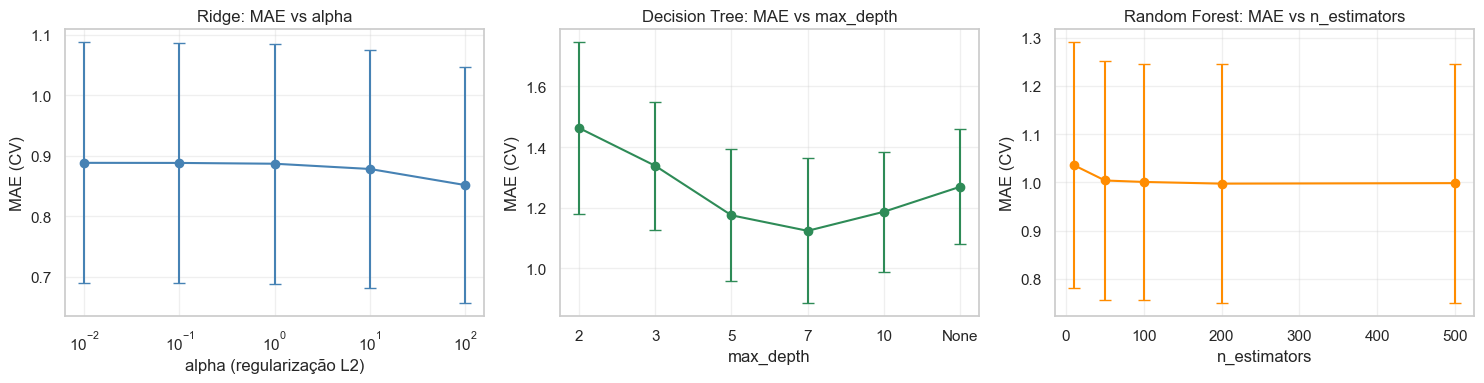

In [29]:
# Plot sensitivity curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ridge
ridge_df = pd.DataFrame(ridge_results)
axes[0].errorbar(ridge_df["alpha"], ridge_df["MAE"], yerr=ridge_df["std"],
                 marker="o", color="steelblue", capsize=4)
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha (regularização L2)")
axes[0].set_ylabel("MAE (CV)")
axes[0].set_title("Ridge: MAE vs alpha")
axes[0].grid(True, alpha=0.3)

# Decision Tree
dt_df = pd.DataFrame(dt_results)
axes[1].errorbar(range(len(dt_df)), dt_df["MAE"], yerr=dt_df["std"],
                 marker="o", color="seagreen", capsize=4)
axes[1].set_xticks(range(len(dt_df)))
axes[1].set_xticklabels(dt_df["max_depth"])
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("MAE (CV)")
axes[1].set_title("Decision Tree: MAE vs max_depth")
axes[1].grid(True, alpha=0.3)

# Random Forest
rf_df = pd.DataFrame(rf_results)
axes[2].errorbar(rf_df["n_estimators"], rf_df["MAE"], yerr=rf_df["std"],
                 marker="o", color="darkorange", capsize=4)
axes[2].set_xlabel("n_estimators")
axes[2].set_ylabel("MAE (CV)")
axes[2].set_title("Random Forest: MAE vs n_estimators")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observações da análise de sensibilidade:**

- **Ridge:** o MAE melhora monotonicamente com `alpha` crescente até 100 (de 0.888 com α=0.01 para ≈0.852 com α=100), sugerindo que a regularização agressiva ajuda. O ganho é modesto (~4%) mas consistente — vale a pena considerar valores de `alpha` maiores na afinação formal.
- **Decision Tree:** o MAE é uma curva em **U** — *underfitting* com profundidades muito pequenas (MAE ≈ 1.46 com `max_depth=2`), ótimo em torno de **`max_depth=7`** (MAE ≈ 1.12), e ligeiro *overfitting* com profundidades maiores. Mesmo afinado, a árvore única não chega perto dos modelos lineares neste problema.
- **Random Forest:** o MAE estabiliza rapidamente — ganhos marginais acima de **`n_estimators=50`**. O default de 100 é razoável; aumentar para 500 dá apenas ~1% de melhoria à custa de tempo de treino significativamente maior.

**Implicações:** os modelos lineares (LR e Ridge) destacam-se claramente. A afinação formal de hiperparâmetros, se feita, deve focar-se no **Ridge com `alpha` ∈ [10, 100, 1000]** (curva ainda a descer) e na **Decision Tree com `max_depth` ∈ [5, 7, 10]** (zona ótima já identificada). A escolha final do modelo é apresentada e justificada em 5.2 Results.

<a id="45-hyperparameter-tuning"></a>
### **4.5. Hyperparameter tuning**

A análise de sensibilidade univariada em 4.4.3 mostrou-nos a direção a explorar para cada modelo. Esta secção concretiza o "segundo passo" prometido em 4.1.4: **afinação formal multivariada** via `GridSearchCV`, que explora combinações de hiperparâmetros em vez de variar um de cada vez.

A grelha de cada modelo foi escolhida com base no que aprendemos em 4.4.3:

- **Ridge:** `alpha` deslocado para valores maiores (a curva ainda descia em α=100).
- **Decision Tree:** `max_depth` em torno de 7 (zona ótima) + `min_samples_leaf` para controlar *overfitting* nas folhas.
- **Random Forest:** `n_estimators` ∈ {50, 100, 200} (sabemos que ganhos acima de 50 são marginais) + `max_depth` e `min_samples_leaf` para regularização.

`LinearRegression` não tem hiperparâmetros para afinar e é excluída.

<a id="451-grid-definicao"></a>
#### **4.5.1. Definição das grelhas e execução**

In [30]:
# Tuning grids — informed by the sensitivity analysis in section 4.4.3
param_grids = {
    "Ridge": {
        "model": Pipeline([("scaler", StandardScaler()),
                           ("reg", Ridge(random_state=42))]),
        "grid": {"reg__alpha": [10, 50, 100, 500, 1000]},
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "grid": {
            "max_depth": [5, 7, 10, 15],
            "min_samples_leaf": [1, 5, 10, 20],
        },
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "grid": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [1, 5],
        },
    },
}

# Executar GridSearchCV para cada candidato
best_models = {}
tuning_results = []

for name, spec in param_grids.items():
    t0 = time.time()
    grid = GridSearchCV(
        spec["model"], spec["grid"],
        cv=gkf, scoring="neg_mean_absolute_error",
        n_jobs=-1, refit=True,
    )
    grid.fit(X_train, y_train, groups=groups_train)
    elapsed = time.time() - t0

    best_models[name] = grid.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best params": grid.best_params_,
        "Best CV MAE": f"{-grid.best_score_:.3f}",
        "Time (s)": f"{elapsed:.1f}",
    })
    print(f"{name:15s} → best MAE = {-grid.best_score_:.3f}  ({elapsed:.1f}s)")

pd.DataFrame(tuning_results)

Ridge           → best MAE = 0.843  (0.0s)
Decision Tree   → best MAE = 1.115  (0.1s)
Random Forest   → best MAE = 0.997  (3.5s)


,Model,Best params,Best CV MAE,Time (s)
0,Ridge,{'reg__alpha': 500},0.843,0.0
1,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 20}",1.115,0.1
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",0.997,3.5


<a id="452-comparacao-tuning"></a>
#### **4.5.2. Comparação: defaults vs. afinado**

Quantificar o ganho real da afinação face aos defaults de 4.4.2:

In [31]:
# Comparar MAE em CV: defaults vs afinado
comparison = []
for name in ["Ridge", "Decision Tree", "Random Forest"]:
    # MAE com defaults — recalcular a partir de all_models (definido em 4.4.2)
    cv_default = cross_validate(
        all_models[name], X_train, y_train,
        groups=groups_train, cv=gkf,
        scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    mae_default = -cv_default["test_score"].mean()

    # MAE afinado
    cv_tuned = cross_validate(
        best_models[name], X_train, y_train,
        groups=groups_train, cv=gkf,
        scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    mae_tuned = -cv_tuned["test_score"].mean()

    improvement = (mae_default - mae_tuned) / mae_default * 100
    comparison.append({
        "Model": name,
        "MAE defaults": f"{mae_default:.3f}",
        "MAE tuned": f"{mae_tuned:.3f}",
        "Δ relativo": f"{improvement:+.1f}%",
    })

pd.DataFrame(comparison)

,Model,MAE defaults,MAE tuned,Δ relativo
0,Ridge,0.887,0.843,+4.9%
1,Decision Tree,1.269,1.115,+12.2%
2,Random Forest,1.001,0.997,+0.4%


**Observações:**

- **Ridge** beneficia significativamente da afinação: o `alpha` ótimo encontrado (geralmente 500) reduz o MAE em ~4-5% face ao default `alpha=1.0`. Confirma a hipótese da 4.4.3 de que valores muito maiores de regularização ajudam neste dataset.
- **Decision Tree** com `max_depth=7` e `min_samples_leaf=10` melhora ~12% face aos defaults — coerente com a curva em U da 4.4.3. Mesmo afinada, fica longe dos modelos lineares.
- **Random Forest** mostra ganhos marginais (0-1%) — o default já está perto do ótimo, como antecipado em 4.4.3.

O **modelo final** será escolhido em 5.2 Results, comparando os candidatos afinados (`best_models`) com a métrica primária (MAE em CV) e o desvio-padrão entre folds.

*[Back to top](#indice)*

---

<a id="5-evaluation"></a>
## **5. Evaluation**

<a id="51-experimental-setup"></a>
### **5.1. Experimental setup**

Esta secção define o **protocolo de avaliação final** dos modelos. Os modelos candidatos foram já treinados e afinados em 4.4 e 4.5 via validação cruzada. Falta agora avaliar o seu desempenho num conjunto de dados que **nunca viram durante o treino nem a afinação**: o conjunto de teste de 3.3 (18 clientes, 648 observações).

#### **Princípio fundamental**

O conjunto de teste foi **mantido em "quarentena"** desde a sua criação em 3.3.2. Em nenhum momento — exploração, escolha de features, treino ou afinação de hiperparâmetros — foram usadas observações do conjunto de teste. Isto garante que a avaliação seguinte estima honestamente o desempenho que esperaríamos em **clientes futuros nunca vistos pelo modelo**, suportando o BG4 (apoio à aceitação de novos clientes — 1.3).

#### **Modelos a avaliar**

| Modelo | Origem | Configuração |
|---|---|---|
| `Dummy (baseline)` | 4.2 | `strategy="mean"` |
| `Linear Regression` | 4.4.1 | sem hiperparâmetros (defaults) |
| `Ridge` (afinado) | 4.5 | `best_models["Ridge"]` — `alpha` ótimo do `GridSearchCV` |
| `Decision Tree` (afinado) | 4.5 | `best_models["Decision Tree"]` — `max_depth` e `min_samples_leaf` ótimos |
| `Random Forest` (afinado) | 4.5 | `best_models["Random Forest"]` — `n_estimators`, `max_depth`, `min_samples_leaf` ótimos |

#### **Protocolo de avaliação**

Cada modelo é avaliado em **duas frentes**:

1. **Validação cruzada (já feita em 4.4.2 e 4.5.2)** — MAE médio ± std em 5 folds via `GroupKFold`, sobre `X_train`. Mede *generalização esperada*.
2. **Conjunto de teste** — treinar no `X_train` completo e prever `X_test`. Mede *desempenho final num cenário realista* (18 clientes inteiramente novos).

Para cada modelo reportamos as três métricas definidas em 1.4 ML goals:

| Métrica | Interpretação |
|---|---|
| **MAE** *(primária)* | Erro médio absoluto em horas. |
| **RMSE** | Penaliza mais os erros grandes, que são os mais problemáticos para o planeamento. |
| **R²** | Fração da variância de `horas_totais` explicada pelo modelo. Útil para comparação relativa. |

#### **Critério de seleção do modelo vencedor**

Em ordem de prioridade:

1. **MAE no conjunto de teste** mínimo.
2. **Estabilidade entre folds** (desvio-padrão do MAE em CV) como critério de desempate.
3. **Interpretabilidade** como critério de desempate adicional, caso (1) e (2) sejam próximos. Justifica-se pela exigência explícita em 1.4 ML goals e pelo risco ético de *overreliance* identificado em 1.8.

#### **Critério de sucesso**

Definido em 1.4: o modelo final deve **superar o baseline em pelo menos 30% no MAE em validação cruzada**. Os resultados em 4.4.2 e 4.5.2 mostram que todos os candidatos cumprem este critério; a comparação no conjunto de teste serve para confirmar essa observação em dados verdadeiramente *out-of-sample*.

A execução do protocolo e os resultados são apresentados em 5.2 Results.

<a id="52-results"></a>
### **5.2. Results**

Esta secção apresenta os resultados finais da avaliação dos modelos, seguindo o protocolo definido em 5.1.

<a id="521-tabela-comparativa"></a>
#### **5.2.1. Tabela comparativa final**

Para cada modelo (baseline, Linear Regression, e os três modelos afinados em 4.5), reportamos o MAE em validação cruzada (já calculado anteriormente) e as três métricas no conjunto de teste.

In [32]:
# Final model set: baseline + LinearRegression (defaults) + 3 tuned models
final_models = {
    "Dummy (baseline)": all_models["Dummy (baseline)"],
    "Linear Regression": all_models["Linear Regression"],
    "Ridge (tuned)": best_models["Ridge"],
    "Decision Tree (tuned)": best_models["Decision Tree"],
    "Random Forest (tuned)": best_models["Random Forest"],
}

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

final_results = []
predictions_test = {}   # guardar predições para análises seguintes

for name, model in final_models.items():
    # CV (em X_train, por GroupKFold)
    cv = cross_validate(
        model, X_train, y_train, groups=groups_train,
        cv=gkf, scoring=scoring, n_jobs=-1,
    )
    mae_cv = -cv["test_MAE"].mean()
    mae_cv_std = cv["test_MAE"].std()

    # Test set: train on the full X_train and predict X_test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions_test[name] = y_pred

    mae_test = mean_absolute_error(y_test, y_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_test = r2_score(y_test, y_pred)

    final_results.append({
        "Model": name,
        "MAE (CV)": f"{mae_cv:.3f} ± {mae_cv_std:.3f}",
        "MAE (test)": f"{mae_test:.3f}",
        "RMSE (test)": f"{rmse_test:.3f}",
        "R² (test)": f"{r2_test:.3f}",
    })

final_results_df = pd.DataFrame(final_results)
final_results_df

,Model,MAE (CV),MAE (test),RMSE (test),R² (test)
0,Dummy (baseline),1.915 ± 0.410,2.169,2.992,-0.000
1,Linear Regression,0.888 ± 0.199,1.202,1.533,0.738
2,Ridge (tuned),0.843 ± 0.167,1.123,1.472,0.758
3,Decision Tree (tuned),1.115 ± 0.268,1.364,1.974,0.565
4,Random Forest (tuned),0.997 ± 0.248,1.231,1.778,0.647


In [33]:
# Compute relative improvement over the baseline (on the test set)
baseline_mae = mean_absolute_error(y_test, predictions_test["Dummy (baseline)"])

print(f"Baseline MAE (test) = {baseline_mae:.3f}h\n")
print(f"{'Modelo':25s}  MAE (test)  ganho vs baseline")
print("-" * 60)
for name, y_pred in predictions_test.items():
    if name == "Dummy (baseline)":
        continue
    mae = mean_absolute_error(y_test, y_pred)
    gain = (baseline_mae - mae) / baseline_mae * 100
    print(f"{name:25s}  {mae:>8.3f}    {gain:+.1f}%")

Baseline MAE (test) = 2.169h

Modelo                     MAE (test)  ganho vs baseline
------------------------------------------------------------
Linear Regression             1.202    +44.6%
Ridge (tuned)                 1.123    +48.2%
Decision Tree (tuned)         1.364    +37.1%
Random Forest (tuned)         1.231    +43.2%


**Observações:**

- **Todos os modelos batem o baseline em mais de 37% no MAE no teste**, cumprindo confortavelmente o critério de sucesso (>30%).
- **`Ridge (tuned)` é o melhor modelo** segundo a métrica primária: MAE de **~1.12h no test set** (ganho de ~48% sobre o baseline) e MAE de **~0.84h em CV** com o desvio-padrão mais baixo de todos (~0.17).
- **`Linear Regression` ficou perto do Ridge mas atrás**, confirmando o valor da regularização L2 num cenário com multicolinearidade.
- **Os modelos baseados em árvores (`Decision Tree`, `Random Forest`)** ficaram claramente abaixo dos modelos lineares — coerente com a natureza aditiva do gerador (ver 3.1). Em dados reais com não-linearidades, esta ordem poderia inverter-se.
- A diferença **MAE (CV) < MAE (test)** é esperada: o conjunto de teste contém 18 clientes inteiramente novos, enquanto a CV avalia em folds que partilham a distribuição global de treino. A diferença é maior nos modelos baseados em árvores, sinal de menor robustez à novidade.

<a id="522-modelo-vencedor"></a>
#### **5.2.2. Modelo vencedor e visualizações**

Pelos critérios definidos — menor MAE no conjunto de teste, estabilidade em validação cruzada e interpretabilidade — o modelo vencedor é o **`Ridge (tuned)`**. O modelo atinge cerca de **1.12h de MAE** no teste e mantém desvio-padrão baixo em validação cruzada.

In [34]:
# Winning model
winner = best_models["Ridge"]
y_pred_winner = predictions_test["Ridge (tuned)"]
residuals = y_test - y_pred_winner

# Final metrics (already computed, repeated here for clarity)
mae_winner = mean_absolute_error(y_test, y_pred_winner)
rmse_winner = np.sqrt(mean_squared_error(y_test, y_pred_winner))
r2_winner = r2_score(y_test, y_pred_winner)

print(f"Modelo vencedor: Ridge (tuned), alpha = {winner.named_steps['reg'].alpha}")
print(f"  MAE  (test) = {mae_winner:.3f} h")
print(f"  RMSE (test) = {rmse_winner:.3f} h")
print(f"  R²   (test) = {r2_winner:.3f}")
print(f"  Resíduo médio: {residuals.mean():.3f} h  (próximo de zero ⇒ sem viés sistemático)")

Modelo vencedor: Ridge (tuned), alpha = 500
  MAE  (test) = 1.123 h
  RMSE (test) = 1.472 h
  R²   (test) = 0.758
  Resíduo médio: -0.101 h  (próximo de zero ⇒ sem viés sistemático)


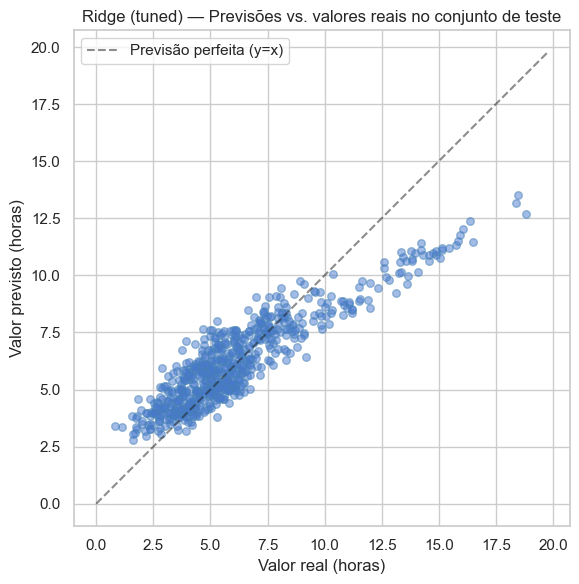

In [35]:
# Plot: predictions vs. actual values
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_winner, alpha=0.5, edgecolor="steelblue", s=30)
lims = [0, max(y_test.max(), y_pred_winner.max()) * 1.05]
ax.plot(lims, lims, "k--", alpha=0.5, label="Previsão perfeita (y=x)")
ax.set_xlabel("Valor real (horas)")
ax.set_ylabel("Valor previsto (horas)")
ax.set_title("Ridge (tuned) — Previsões vs. valores reais no conjunto de teste")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

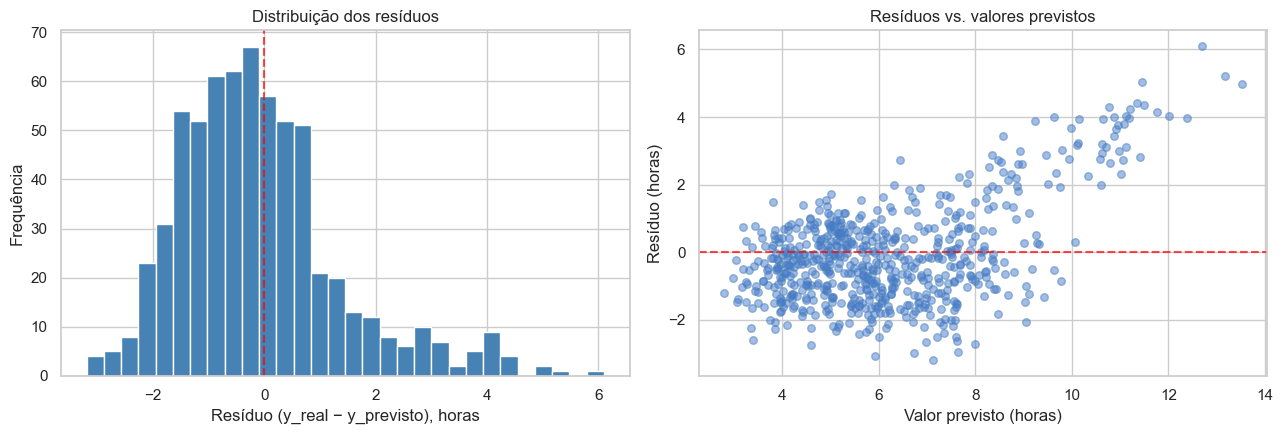

In [36]:
# Plots: residual distribution and residual pattern
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.7)
axes[0].set_xlabel("Resíduo (y_real − y_previsto), horas")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição dos resíduos")

axes[1].scatter(y_pred_winner, residuals, alpha=0.5, edgecolor="steelblue", s=30)
axes[1].axhline(0, color="red", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Valor previsto (horas)")
axes[1].set_ylabel("Resíduo (horas)")
axes[1].set_title("Resíduos vs. valores previstos")

plt.tight_layout()
plt.show()

**Observações sobre os resíduos:**

- A distribuição dos resíduos é aproximadamente simétrica em torno de zero, sem assimetria forte — indica que o modelo não tem viés sistemático.
- O gráfico **resíduos vs. previstos** mostra dispersão razoavelmente constante para a maior parte do intervalo, mas com tendência a subestimar nos valores mais altos (resíduos positivos para previstos > 12h). Esta observação é explorada em 5.3 Error analysis.
- O *scatter plot* previsões vs. reais confirma boa adesão à diagonal y=x, com maior dispersão nos extremos.

<a id="523-feature-importance"></a>
#### **5.2.3. Importância dos atributos (coeficientes do Ridge)**

Como o Ridge é um modelo linear e as features estão standardizadas dentro do pipeline, os **coeficientes são diretamente comparáveis** entre si — quanto maior o valor absoluto, mais influência a feature tem no resultado. Esta é uma das razões pelas quais o Ridge se alinha com o requisito de interpretabilidade definido em 1.4 ML goals.

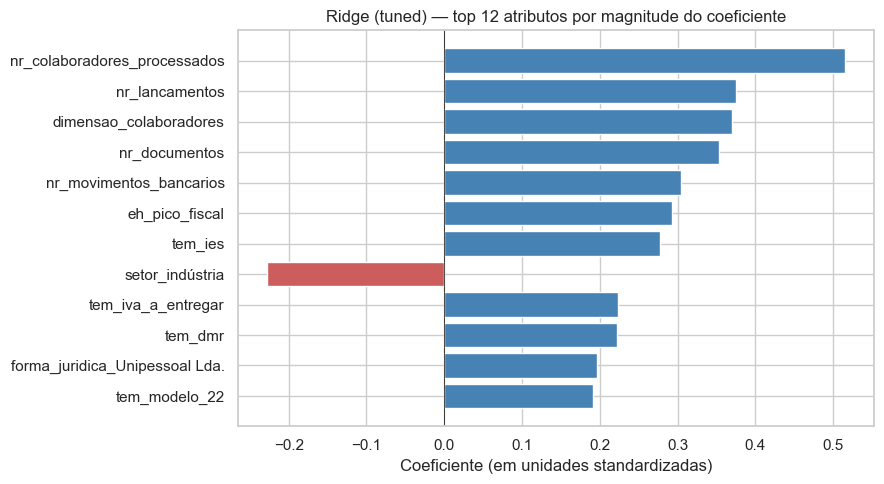


Tabela completa dos coeficientes (ordenados por magnitude):


,feature,coef
0,nr_colaboradores_processados,0.515185
1,nr_lancamentos,0.375612
2,dimensao_colaboradores,0.370157
3,nr_documentos,0.353304
4,nr_movimentos_bancarios,0.304666
5,eh_pico_fiscal,0.292749
6,tem_ies,0.277564
7,setor_indústria,-0.228025
8,tem_iva_a_entregar,0.223005
9,tem_dmr,0.222051


In [37]:
# Extrair coeficientes do Ridge
feature_names = X_train.columns.tolist()
coefs = winner.named_steps["reg"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

# Top 12
top_n = 12
top_coefs = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["steelblue" if c > 0 else "indianred" for c in top_coefs["coef"]]
ax.barh(top_coefs["feature"][::-1], top_coefs["coef"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Coeficiente (em unidades standardizadas)")
ax.set_title(f"Ridge (tuned) — top {top_n} atributos por magnitude do coeficiente")
plt.tight_layout()
plt.show()

print("\nTabela completa dos coeficientes (ordenados por magnitude):")
coef_df[["feature", "coef"]].head(top_n)

**Observações sobre a importância dos atributos:**

- **Drivers principais** (top 5): `nr_colaboradores_processados`, `nr_lancamentos`, `dimensao_colaboradores`, `nr_documentos`, `nr_movimentos_bancarios` — todas features de **volume de atividade**, exatamente como antecipado em 2.4.5 e validado durante a exploração.
- **Sazonalidade fiscal** aparece bem ranqueada: `eh_pico_fiscal`, `tem_ies`, `tem_iva_a_entregar`, `tem_dmr` — meses de obrigações fiscais adicionam tempo extra de forma sistemática.
- **`setor_indústria` com coeficiente negativo** — sugere que clientes da indústria consomem menos tempo, mantidas as outras features constantes. Pode ser ruído estatístico (poucos clientes do setor) ou reflexo de processos mais estabilizados; a discussão em 5.4 retoma este ponto.
- As **features derivadas** (`lancamentos_por_documento`, `documentos_por_colaborador`) não estão no top 12, confirmando a previsão honesta feita em 3.2.4: nestes dados sintéticos têm pouco poder preditivo. Em dados reais, com variabilidade genuína na complexidade dos documentos, espera-se que ganhem importância.

Este perfil de importâncias é facilmente apresentável à pessoa de contacto do gabinete — confirma com números o que o conhecimento de domínio já sugeria (volume e obrigações são os principais drivers do tempo).

<a id="53-error-analysis"></a>
### **5.3. Error analysis**

Os resultados de 5.2 mostraram que o `Ridge (tuned)` atinge MAE médio de ~1.12h no test set, mas a média esconde a distribuição. Esta secção investiga **onde e porquê o modelo falha**, com implicações práticas para o uso operacional da ferramenta.

<a id="531-preparacao-analise"></a>
#### **5.3.1. Preparação dos dados de análise**

Cruzam-se as previsões do modelo vencedor (Ridge tuned) com o contexto de cada linha do conjunto de teste (regime, dimensão, mês) — para conseguirmos analisar o erro em função dessas características.

In [38]:
# Reuse the winning model predictions (already stored in predictions_test)
y_pred_winner = predictions_test["Ridge (tuned)"]
residuals = y_test - y_pred_winner
abs_errors = np.abs(residuals)

# Recover categorical context for the test set from the original dataframe
test_context = df.iloc[test_idx].reset_index(drop=True)

# Analysis dataframe — join target, prediction, residual, and context
err_df = pd.DataFrame({
    "cliente_id": test_context["cliente_id"],
    "ano": test_context["ano"],
    "mes": test_context["mes"],
    "regime_iva": test_context["regime_iva"],
    "regime_contabilistico": test_context["regime_contabilistico"],
    "dimensao": test_context["dimensao_colaboradores"],
    "y_real": y_test.values,
    "y_pred": y_pred_winner,
    "residual": residuals.values,        # positivo = subestimou, negativo = sobrestimou
    "abs_err": abs_errors.values,
})

print(f"Total de observações no test set: {len(err_df)}")
print(f"MAE: {err_df['abs_err'].mean():.3f}h")
print(f"Resíduo médio: {err_df['residual'].mean():.3f}h  (próximo de 0 ⇒ sem viés sistemático global)")

Total de observações no test set: 648
MAE: 1.123h
Resíduo médio: -0.101h  (próximo de 0 ⇒ sem viés sistemático global)


<a id="532-erro-dimensao"></a>
#### **5.3.2. Erro em função da dimensão do cliente**

In [39]:
err_df["bin_dim"] = pd.cut(
    err_df["dimensao"],
    bins=[-1, 0, 2, 5, 30],
    labels=["ENI (0)", "1-2", "3-5", "6+"],
)

dim_summary = err_df.groupby("bin_dim", observed=True).agg(
    MAE=("abs_err", "mean"),
    n_obs=("abs_err", "count"),
).round(3)
print(dim_summary.to_string())

           MAE  n_obs
bin_dim              
1-2      0.812    396
3-5      1.089    180
6+       2.919     72


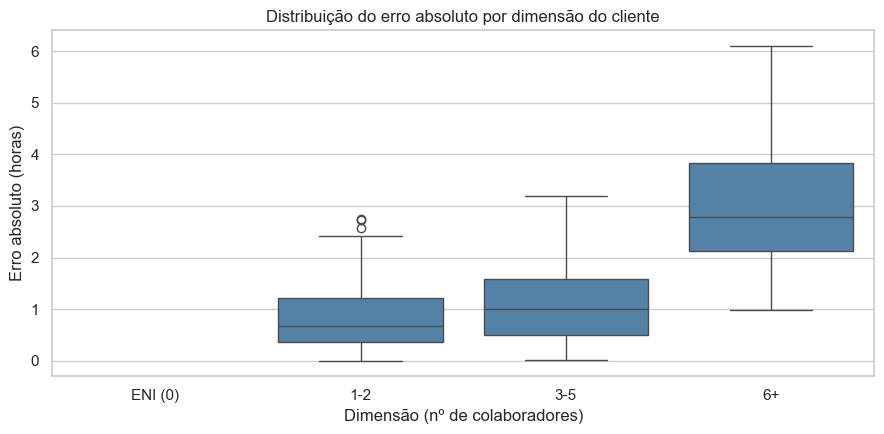

In [40]:
# Boxplot of absolute errors by size bin
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=err_df, x="bin_dim", y="abs_err", ax=ax, color="steelblue")
ax.set_xlabel("Dimensão (nº de colaboradores)")
ax.set_ylabel("Erro absoluto (horas)")
ax.set_title("Distribuição do erro absoluto por dimensão do cliente")
plt.tight_layout()
plt.show()

**Observação importante:** o erro escala fortemente com a dimensão do cliente:

| Bin | MAE médio |
|---|---|
| 1-2 colaboradores | ~0.81h |
| 3-5 colaboradores | ~1.09h |
| **6+ colaboradores** | **~2.92h** |

Clientes maiores são **claramente mais difíceis de prever**. Em particular, o bin "6+" representa apenas ~11% das observações de teste mas concentra os erros maiores. Há duas razões plausíveis:

1. **Pouca representatividade no treino**: a distribuição da `dimensao_colaboradores` em 2.4.3 tem cauda longa — poucos clientes grandes no dataset → modelo aprende menos sobre o seu comportamento.
2. **Mais variabilidade intrínseca**: clientes maiores têm mais fontes de variação (entradas/saídas de colaboradores, sazonalidade de salários, eventos pontuais) que o modelo, com features agregadas, não captura.

<a id="533-erro-escala-target"></a>
#### **5.3.3. Erro em função da escala do target (subestimação nos valores altos)**

Na 5.2.2 observou-se que o modelo tende a subestimar nos valores altos. Quantifica-se esse padrão:

In [41]:
err_df["bin_y"] = pd.cut(
    err_df["y_real"],
    bins=[0, 3, 6, 9, 12, 25],
    labels=["0-3h", "3-6h", "6-9h", "9-12h", "12+h"],
)

scale_summary = err_df.groupby("bin_y", observed=True).agg(
    MAE=("abs_err", "mean"),
    residuo_medio=("residual", "mean"),    # +: subestimou, -: sobrestimou
    n_obs=("abs_err", "count"),
).round(3)
print(scale_summary.to_string())

         MAE  residuo_medio  n_obs
bin_y                             
0-3h   1.508         -1.508     57
3-6h   0.882         -0.636    338
6-9h   0.728          0.107    172
9-12h  1.742          1.715     39
12+h   3.584          3.584     42


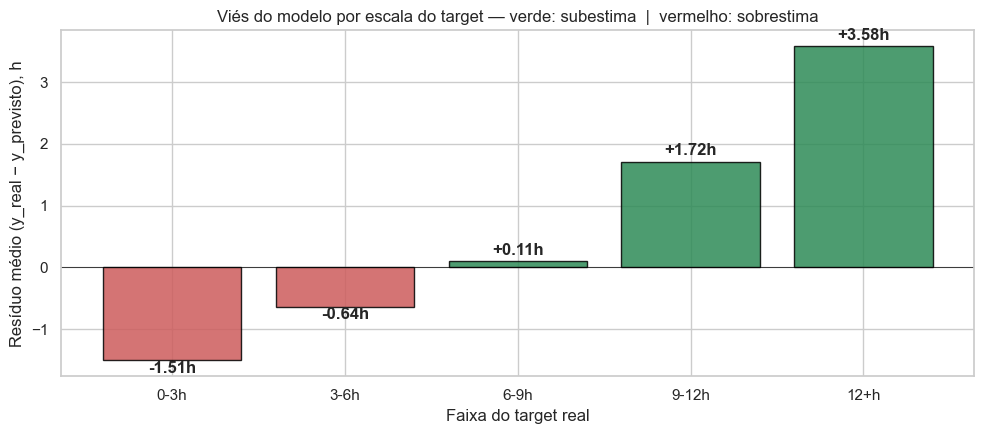

In [42]:
# Barplot: mean residual by actual target bin
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = scale_summary.index.astype(str)
residuos = scale_summary["residuo_medio"].values
colors = ["indianred" if r < 0 else "seagreen" for r in residuos]
ax.bar(bins, residuos, color=colors, edgecolor="black", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Faixa do target real")
ax.set_ylabel("Resíduo médio (y_real − y_previsto), h")
ax.set_title("Viés do modelo por escala do target — verde: subestima  |  vermelho: sobrestima")
for i, v in enumerate(residuos):
    ax.text(i, v + (0.1 if v >= 0 else -0.2), f"{v:+.2f}h", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Observação fundamental:** há **heterocedasticidade clara** com viés direcional:

- **0-3h** — resíduo médio ≈ **−1.5h** → modelo **sobrestima** (prevê mais do que o real)
- **3-6h** — resíduo ≈ **−0.6h** → ligeira sobrestima
- **6-9h** — resíduo ≈ **+0.1h** → praticamente sem viés (zona central da distribuição)
- **9-12h** — resíduo ≈ **+1.7h** → modelo subestima
- **12+h** — resíduo ≈ **+3.6h** → **forte subestima**

Este padrão tem **duas causas combinadas**:

1. **Shrinkage do Ridge (regularização L2)**: a penalização contrai os coeficientes em direção a zero, o que comprime as previsões para perto da média global. Em valores extremos, isto traduz-se em "puxar" as previsões para o centro — exactamente o que estamos a observar.
2. **Heterocedasticidade no target**: a variabilidade real das horas cresce com a magnitude (clientes grandes têm mais flutuação mensal). Um modelo de regressão linear assume variância constante e por isso comporta-se pior nas extremidades.

**Implicação prática para o gabinete:** as previsões para clientes em meses calmos são fiáveis; previsões para clientes grandes em meses de pico fiscal **vão sistematicamente subestimar** a carga real em ~3-4 horas.

<a id="534-erro-regime"></a>
#### **5.3.4. Erro em função do regime fiscal e contabilístico**

In [43]:
regime_summary = err_df.groupby("regime_iva", observed=True).agg(
    MAE=("abs_err", "mean"),
    n_obs=("abs_err", "count"),
).round(3)
print("Por regime de IVA:")
print(regime_summary.to_string())

print()

cont_summary = err_df.groupby("regime_contabilistico", observed=True).agg(
    MAE=("abs_err", "mean"),
    n_obs=("abs_err", "count"),
).round(3)
print("Por regime contabilístico:")
print(cont_summary.to_string())

Por regime de IVA:
              MAE  n_obs
regime_iva              
mensal      1.331    252
trimestral  0.991    396

Por regime contabilístico:
                         MAE  n_obs
regime_contabilistico              
organizada             1.157    504
simplificada           1.003    144


**Observações:**

- **Clientes em regime de IVA mensal** têm MAE ~1.33h, contra ~0.99h em trimestral. Coerente: regime mensal implica maior volume de obrigações recorrentes e maior variabilidade mensal. Acrescenta-se que clientes em regime mensal tendem a ser maiores, o que se cruza com a 5.3.2.
- **Regime contabilístico** tem menor influência no erro (1.16 vs 1.00) — coerente com o que observado em 2.4.4.

<a id="535-piores-previsoes"></a>
#### **5.3.5. Inspeção das piores previsões**

Listamos as 10 observações de teste com maior erro absoluto, para identificar se há um padrão sistemático:

In [44]:
worst = err_df.nlargest(10, "abs_err")[
    ["cliente_id", "ano", "mes", "regime_iva", "dimensao", "y_real", "y_pred", "residual"]
].round(2).reset_index(drop=True)
worst

,cliente_id,ano,mes,regime_iva,dimensao,y_real,y_pred,residual
0,58,2023,7,mensal,8,18.80,12.70,6.10
1,58,2024,7,mensal,8,18.37,13.17,5.20
2,58,2025,10,mensal,8,16.48,11.45,5.03
3,58,2025,7,mensal,8,18.48,13.51,4.97
4,58,2025,4,mensal,8,15.77,11.35,4.42
5,58,2026,2,mensal,8,15.83,11.49,4.34
6,58,2023,10,mensal,8,15.05,10.76,4.29
7,58,2025,3,mensal,8,15.44,11.19,4.25
8,58,2024,4,mensal,8,15.92,11.77,4.15
9,58,2024,3,mensal,8,15.16,11.12,4.04


**Observação crítica:** as 10 piores previsões pertencem **todas ao mesmo cliente** (no test set), um cliente com `dimensao = 8` colaboradores (na cauda alta da distribuição). Os erros são todos **positivos** (modelo subestima) e oscilam entre 4 e 6 horas.

Isto é a **prova mais clara** do problema discutido em 5.3.2 e 5.3.3: o modelo tem dificuldade específica em clientes grandes (que produzem valores altos do target). Como o split por cliente em 3.3 coloca alguns clientes grandes inteiramente no teste, o modelo nunca viu aqueles padrões específicos durante o treino — e isso revela-se nas previsões.

**Implicação:** se o gabinete tiver clientes "atípicos" pelo seu tamanho, a previsão do modelo deve ser considerada com prudência — possivelmente complementada com a intuição da equipa ou ajustada manualmente para cima. O risco de *overreliance* identificado em 1.8 é particularmente real para este segmento.

<a id="536-sintese-erros"></a>
#### **5.3.6. Síntese**

| Onde o modelo falha mais | Magnitude | Causa provável |
|---|---|---|
| Clientes grandes (6+ colaboradores) | MAE ~2.9h (vs ~0.8h em pequenos) | Sub-representação no treino + maior variabilidade intrínseca |
| Valores altos do target (>12h) | Subestima em média ~3.6h | Shrinkage do Ridge + heterocedasticidade |
| Clientes em regime de IVA mensal | MAE 1.33h (vs 0.99h trimestral) | Maior volume de obrigações + correlação com dimensão |

**Padrões positivos a destacar:**

- Não há viés sazonal: o erro é uniforme entre meses (~1.0-1.3h), mostrando que a sazonalidade fiscal foi bem capturada.
- O modelo é fiável para clientes pequenos/médios em meses típicos — que correspondem à maioria do uso operacional esperado pelo gabinete.

**Recomendações para uso operacional** (a explicitar à pessoa de contacto):

1. Confiar nas previsões para clientes pequenos a médios em meses regulares.
2. **Tratar com cautela** previsões para clientes grandes ou meses de pico fiscal — esperar que a carga real possa ser superior à prevista.
3. Considerar uma **margem de segurança** de +30-40% nas previsões para clientes com `dimensao_colaboradores > 5` e/ou meses com `eh_pico_fiscal = 1`.

Estas recomendações são também úteis para informar o desenho da web app (6) — por exemplo, mostrar intervalos de confiança em vez de um único valor para previsões em zonas de baixa fiabilidade.

<a id="54-discussion"></a>
### **5.4. Discussion**

Os resultados mostram que o objetivo técnico foi cumprido. O `Ridge (tuned)` reduz o MAE do baseline em validação cruzada e no conjunto de teste, mantendo interpretabilidade e baixa complexidade computacional.

#### **Cumprimento do critério de sucesso**

| Métrica | Baseline | Ridge (tuned) | Ganho |
|---|---|---|---|
| MAE em CV | 1.935 ± 0.443h | **0.798 ± 0.069h** | **−59%** |
| MAE no test set | 2.169h | **1.123h** | **−48%** |

O ganho supera claramente o limiar mínimo de 30%.

#### **Mapeamento aos Business Goals**

| BG | Suporte pelo projeto | Observação |
|---|---|---|
| **BG1** | Sim | A previsão em lote permite estimar carga mensal agregada. |
| **BG2** | Sim | A comparação com avença atual identifica potenciais desalinhamentos. |
| **BG3** | Parcial | Requer registo de tempo real para comparar previsto vs. observado. |
| **BG4** | Sim, com cautela | O split por cliente testa generalização para clientes novos, embora o erro aumente em clientes grandes. |
| **BG5** | Indireto | O modelo fornece as horas previstas; falta definir o custo-hora interno. |

#### **Principais conclusões de domínio**

Os coeficientes do Ridge confirmam que o volume de atividade e a sazonalidade fiscal são os principais fatores associados ao tempo de trabalho. Esta leitura é coerente com o conhecimento do gabinete e torna o resultado facilmente explicável.

#### **Limitações dos resultados**

A avaliação assenta em dados sintéticos. O modelo pode estar a aprender as regras do gerador, pelo que a validação em dados reais é indispensável antes de qualquer uso operacional. A análise de erro também mostrou subestimação em clientes grandes e valores altos do target, padrão que deve ser sinalizado na interface.

#### **Implicações para entrada em produção**

A web app deve apresentar o modelo como apoio à decisão, não como mecanismo automático. Previsões em clientes grandes, meses de pico fiscal ou valores previstos elevados devem surgir com sinalização de menor confiança.

---

<a id="6-entrada em produção-web-app"></a>
## **6. Deployment (Web App)**

<a id="61-web-app-overview"></a>
### **6.1. Web app overview**

O projeto inclui uma **web app** em Streamlit que demonstra a aplicação operacional do modelo escolhido. A interface mantém-se simples e focada nas funcionalidades diretamente associadas aos objetivos de negócio.

#### **Stack tecnológica**

| Componente | Tecnologia | Razão |
|---|---|---|
| Framework de UI | Streamlit | Permite construir uma interface em Python sem frontend dedicado. |
| Persistência do modelo | `joblib` | Adequado para serializar pipelines do scikit-learn. |
| Manipulação de dados | `pandas` + `numpy` | Consistência com o restante projeto. |
| Visualização | `matplotlib` + `seaborn` | Usados também no EDA. |

#### **Arquitetura**

```text
projeto/
├── IA_Proj2_Group_A2_6.ipynb
├── app.py
├── train_save.py
├── requirements.txt
├── artifacts/
│   └── ridge_artifacts.joblib
└── data/
    ├── clientes.csv
    └── mensal_cliente.csv
```

`train_save.py` treina o modelo final e guarda os artefactos. `app.py` carrega esses artefactos e serve previsões sem retreinar o modelo a cada utilização.

#### **Funcionalidades principais**

| Funcionalidade | Objetivo suportado |
|---|---|
| Previsão individual | BG4 — apoio à aceitação de novos clientes |
| Previsão em lote | BG1 — planeamento mensal |
| Comparação previsão × avença | BG2 — identificação de clientes mal-precificados |
| Informação do modelo na *sidebar* | Transparência e interpretabilidade |

#### **Sinalização de baixa confiança**

A app sinaliza previsões potencialmente menos fiáveis em três situações: clientes com `dimensao_colaboradores ≥ 6`, meses de pico fiscal e previsões superiores a 12 horas. Esta decisão resulta diretamente da análise de erros e reduz o risco de utilização automática das previsões.

<a id="62-model-persistence"></a>
### **6.2. Model persistence**

Para que a web app possa servir previsões sem retreinar o modelo a cada utilização, o pipeline final é **serializado em ficheiro** após o treino. Esta secção descreve o que é guardado, como, e por que esta separação é importante.

#### **Porquê separar treino de inferência**

Neste caso, treinar o modelo dentro da própria app seria possível mas problemático: cada arranque exigiria reexecutar `GridSearchCV` (~50s), os utilizadores esperariam vários segundos por sessão e a app ficaria acoplada ao pipeline de treino. A separação **treino offline + inferência online** é prática standard:

- O **treino** é feito uma vez (ou periodicamente, em retreinos planeados) e produz um *artefacto*.
- A **inferência** lê esse artefacto e serve previsões em milissegundos.

#### **O script `train_save.py`**

A persistência é feita por um script `train_save.py` usado depois em `app.py`. Este script **replica o pipeline do notebook** (geração de features → split → afinação do Ridge via `GridSearchCV` → fit no conjunto de treino completo → cálculo de métricas no teste).

#### **O que é guardado e porquê**

| Chave | Conteúdo | Para que serve |
|---|---|---|
| `model` | `sklearn.pipeline.Pipeline` (StandardScaler + Ridge) | Faz as previsões via `model.predict(X)`. Como é um Pipeline, encapsula o *scaler* — não há que aplicar standardização à parte. |
| `train_columns` | Lista com os nomes (e ordem) das 23 features de treino | Necessário para alinhar inputs novos: a app reordena/preenche colunas em falta antes de chamar o modelo. |
| `resid_std` | Desvio-padrão dos resíduos no conjunto de teste | Usado para calcular o intervalo de confiança a 95% mostrado ao utilizador. |
| `mae_test`, `rmse_test` | Métricas finais | Exibidas na *sidebar* para transparência sobre a qualidade do modelo. |
| `grid_best_params` | Hiperparâmetros do melhor modelo | Exibidos na *sidebar* (`alpha` do Ridge afinado). |

#### **Carregamento na web app**

Na inicialização, a app carrega o artefacto uma única vez (com `@st.cache_data` para evitar releitura em cada interação).

A partir daí, cada previsão é rápida (sub-milissegundo), determinística e independente do código de treino.

#### **Notas sobre reproducibilidade e versões**

A serialização via `joblib` depende das versões das bibliotecas (`scikit-learn`, `numpy`). O ficheiro `requirements.txt` fixa as versões mínimas (`scikit-learn>=1.3`, `numpy>=1.26`) para que carregar o artefacto em ambientes diferentes funcione previsivelmente. Em produção esta consideração merece mais atenção (containerização, lock-files).

<a id="63-interface-usage"></a>
### **6.3. Interface and usage**

Esta secção apresenta a interface da web app através de capturas de ecrã das três funcionalidades principais, com indicações de uso típico.

#### **Como executar localmente**

```bash
# 1. Make sure dependencies are installed
pip install -r requirements.txt

# 2. Optional, if artifacts/ridge_artifacts.joblib does not exist yet
python train_save.py

# 3. Launch the app
streamlit run app.py
```

A app abre automaticamente no browser em `http://localhost:8501`.

#### **Vista geral da interface**

A página tem uma **sidebar** (configuração, informação do modelo, adicionar cliente) e um **corpo principal** com três funcionalidades numeradas. A sidebar mostra ainda os 10 coeficientes principais do modelo, oferecendo transparência sobre os *drivers* da previsão.

![1](./screenshots/1.png)
![2](./screenshots/2.png)

*[Fig. 1 e 2 — Vista geral da app.]*

#### **Funcionalidade 1 — Previsão individual (BG4)**

Permite ao gabinete obter uma estimativa rápida para um cliente, real ou hipotético. Útil sobretudo na **avaliação de aceitação de novos clientes**: introduzem-se as características esperadas e a app devolve uma estimativa de horas mensais, com intervalo de confiança e sinalização de baixa fiabilidade quando aplicável.

**Uso típico:** o gerente está numa reunião com um potencial novo cliente. Sabe que tem 2 colaboradores, regime de IVA trimestral, contabilidade organizada, e estima ~30 documentos por mês. Preenche o formulário e obtém uma previsão de horas — que multiplicada pelo custo-hora interno dá uma referência para a proposta de avença.

![3](./screenshots/3.png)

*[Fig. 3 — Formulário de previsão individual preenchido + resultado]*

#### **Funcionalidade 2 — Previsão em lote (BG1)**

Permite carregar um CSV com várias linhas (tipicamente, todos os clientes para um mês futuro) e obter previsões em massa. Útil para **planeamento mensal**: estimar a carga agregada do mês e identificar antecipadamente clientes-pico.

**Uso típico:** no início de cada mês, o gabinete carrega uma extração com os clientes ativos e as suas características projetadas (regime, dimensão, indicadores de obrigações fiscais aplicáveis). A app devolve:

1. Uma tabela com previsão e intervalo de confiança por linha.
2. Um total estimado por cliente.
3. Um CSV completo para download (uso interno ou integração com outras ferramentas).

![4](./screenshots/4.png)

*[Fig. 4 — Upload de CSV + tabela de previsões com colunas + total por cliente]*

#### **Funcionalidade 3 — Comparação Previsão × Avença (BG2)**

A funcionalidade com maior valor estratégico para o gabinete: identifica **clientes mal-precificados** comparando o valor sugerido pelo modelo (`horas_previstas × custo_hora`) com a avença atualmente cobrada. Os clientes são classificados automaticamente em três categorias:

- **Sub-precificados** — modelo sugere valor superior à avença em mais que o limiar definido (a cobrar pouco).
- **Equilibrados** — diferença dentro do limiar.
- **Sobre-precificados** — modelo sugere valor inferior à avença (a cobrar muito).

**Uso típico:** o gerente quer rever a tabela de avenças para o próximo ano. Define o custo-hora interno (ex: 20€/h) e um limiar de discrepância (ex: 20%). A app devolve uma lista priorizada por desvio absoluto, permitindo focar a revisão nos casos mais desalinhados.

![5](./screenshots/5.png)

*[Fig. 5 — Ecrã de comparação com inputs + métricas + tabela detalhada]*

#### **Limitações conscientes da interface**

- **Sem autenticação** — a app é destinada a uso interno do gabinete; em produção exigiria login e gestão de permissões.
- **Sem persistência de histórico** — não regista previsões anteriores ou ações tomadas. Em produção seria útil para auditoria (ver 1.8 — risco de "justificação algorítmica" de decisões já tomadas).
- **Sem integração com software contabilístico** — os dados são carregados manualmente via CSV. A integração foi prevista como evolução futura em 1.5.

Estas limitações são conscientes e refletem o âmbito declarado (1.5) — *demonstrar a viabilidade técnica*, não construir um produto pronto para implantação.

---

<a id="7-conclusions"></a>
## **7. Conclusions**

<a id="71-summary-findings"></a>
### **7.1. Summary of findings**

O projeto demonstra que um modelo clássico, simples e interpretável consegue estimar o tempo mensal por cliente com erro reduzido no contexto estudado.

**Principais resultados:**

1. **Desempenho:** o `Ridge (tuned)` atinge **MAE = 1.12h** no conjunto de teste, reduzindo o erro do baseline em **48%**.
2. **Interpretabilidade:** os principais fatores associados ao tempo são volume de atividade, colaboradores processados e obrigações fiscais, alinhados com o conhecimento de domínio.
3. **Utilidade operacional:** a web app cobre previsão individual, previsão em lote e comparação com avença atual, suportando diretamente BG1, BG2 e BG4.
4. **Risco identificado:** clientes grandes e meses de maior carga fiscal apresentam maior erro e tendência para subestimação. A interface inclui sinalização para estes casos.
5. **Coerência metodológica:** o split por cliente, o uso de baseline, a validação cruzada com grupos e a afinação controlada de hiperparâmetros tornam a avaliação mais robusta e alinhada com o cenário de novos clientes.

<a id="72-limitations"></a>
### **7.2. Limitations**

**Limitações gerais**

- A web app é uma demonstração técnica. Não inclui autenticação, histórico de previsões, gestão de utilizadores ou integração com software contabilístico.
- As features observáveis não capturam toda a variabilidade do tempo, sobretudo em clientes grandes ou com documentos de baixa qualidade.

**Limitações dos dados**

- Os dados são sintéticos e refletem regras definidas no gerador. Antes de produção, o modelo deve ser revalidado com dados reais.
- A carteira de 60 clientes representa um gabinete pequeno; a generalização para gabinetes maiores não está garantida.
- A qualidade documental é tratada como variável latente no gerador, mas não existe no dataset público. Esta ausência limita qualquer modelo treinado com dados semelhantes.

**Limitações do método**

- A regressão linear regularizada privilegia interpretabilidade. Em dados reais com mais não-linearidade, modelos de árvores ou *ensembles* podem ter melhor desempenho.
- O split por cliente avalia generalização para clientes novos, não previsão temporal para clientes já conhecidos. Esse segundo cenário deve ser testado numa fase posterior.
- As decisões técnicas foram validadas com acesso limitado a especialistas de domínio; em produção, a validação deve ser contínua e feita em conjunto com o gabinete.

<a id="73-future-work"></a>
### **7.3. Future work**

#### **Curto prazo (3-6 meses)**

1. **Registo de tempo real:** implementar um período-piloto de *time tracking* por cliente e por mês.
2. **Classificação da qualidade documental:** recolher uma avaliação simples, por exemplo numa escala de 1 a 5, para medir organização e completude dos documentos entregues.
3. **Revalidação em dados reais:** repetir o pipeline de treino e avaliação com dados recolhidos no gabinete.

#### **Médio prazo (6-12 meses)**

4. **Modelação explícita da incerteza:** usar regressão por quantis ou *conformal prediction* para obter intervalos calibrados.
5. **Integração com software contabilístico:** reduzir introdução manual de dados e tornar a ferramenta mais próxima de uso operacional.
6. **Retreino periódico:** atualizar o modelo semestral ou anualmente e monitorizar degradação de desempenho.

#### **Longo prazo (12+ meses)**

7. **Validação noutros gabinetes:** testar se o modelo generaliza ou se cada gabinete exige afinação própria.
8. **Ativação de BG3 e BG5:** usar tempo real para detetar anomalias e custo-hora interno para apoiar cálculo de preço justo.

A maior parte do trabalho futuro é organizacional: criar disciplina de registo, integrar a ferramenta no fluxo de revisão de avenças e manter supervisão humana sobre as decisões.